In [16]:
import csv
from datetime import datetime
import numpy as np
import trompy as tp

def get_FEDevents(filename, eventname):
    formats = ['%Y-%m-%d %H:%M:%S', '%m/%d/%Y %H:%M:%S']
    
    try:
        file = open(filename)
    except FileNotFoundError:
        print(f"File not found: {filename}")
        return []
    
    csvreader = csv.reader(file)
    next(csvreader)  # Skip header
    rows = []
    for row in csvreader:
        rows.append(row)

    # Check if rows are empty
    if len(rows) == 0:
        print(f"No data found in file: {filename}")
        return []

    # Determine which format should be used
    try:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[0])
        date_format = formats[0]
    except ValueError:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[1])
        date_format = formats[1]

    timestamps = []
    for row in rows: 
        if row[7] == eventname:  # Check event column
            date_time_obj = datetime.strptime(row[0], date_format)
            timestamps.append(date_time_obj)

    if len(timestamps) == 0:
        print(f"No {eventname} events found in file: {filename}")
        return []

    t0 = rows[0][0]
    day = t0.split()[0] 
    lightson = day + " 07:00:00"
    refpoint = datetime.strptime(lightson, date_format)
    
    pellettimes = []
    for t in timestamps:
        Deltat = t - refpoint
        Deltatinseconds = Deltat.total_seconds()
        Deltatinhours = Deltatinseconds / 3600
        pellettimes.append(Deltatinhours)

    return pellettimes
def get_data_subset(dictionary, selectors, verbose=True):
    output_dictionary = dictionary.copy()
    for key, value in selectors.items():
        for mouse_id in dictionary.keys():
            try:
                if output_dictionary[mouse_id][key] != value:
                    output_dictionary.pop(mouse_id)
            except KeyError: 
                pass

    if verbose:
        print("{} items in output dictionary".format(len(output_dictionary.keys())))
    
    return output_dictionary

def get_data_fields(dictionary, fields, selectors):
    output_list = []
    reduced_dictionary = get_data_subset(dictionary, selectors)
    
    if len(reduced_dictionary.keys()) > 0:
        for field in fields:
            output_sublist = []
            try:
                for key in reduced_dictionary.keys():
                    output_sublist.append(reduced_dictionary[key][field])
            except KeyError:
                print("{} is not a key in selected dictionary".format(field))
                return
            output_list.append(output_sublist)
    else:
        print("No data in fields in selected dictionary")

    if len(output_list) == 1:
        output_list = output_list[0]
        
    return output_list

# Function to get meal, snack, and mega meal metrics, including mega_meal_frequency and mega_meal_size
def get_meal_and_snack_metrics(pellettimes, meal_threshold=1/60):
    if not pellettimes:
        return (0, 0, 0, 0, 0, 0, 0, 0, [[0]*24]*7, [[0]*24]*7, [[0]*24]*7, 0, 0, 0, 0, [], [])

    IPIs = np.diff(np.array(pellettimes))
    meals = []
    snacks = []
    mega_meals = []
    IMIs = []
    current_event = [pellettimes[0]]

    # Hourly tracking for each day
    hourly_meals_per_day = [[0]*24 for _ in range(7)]
    hourly_snacks_per_day = [[0]*24 for _ in range(7)]
    hourly_mega_meals_per_day = [[0]*24 for _ in range(7)]

    for i, ipi in enumerate(IPIs):
        if ipi <= meal_threshold:
            current_event.append(pellettimes[i + 1])
        else:
            if len(current_event) == 1:
                snacks.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:  # Make sure we are within the 7-day boundary
                    hourly_snacks_per_day[day_index][hour] += 1
            elif 2 <= len(current_event) <= 4:
                meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_meals_per_day[day_index][hour] += 1
            elif len(current_event) >= 5:
                mega_meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_mega_meals_per_day[day_index][hour] += 1
            IMIs.append(ipi)  # Store IMI as a list of timestamps
            current_event = [pellettimes[i + 1]]

    # Handle the last sequence
    if current_event:
        day_index = int(current_event[0] // 24)
        hour = int(current_event[0]) % 24
        if len(current_event) == 1:
            snacks.append(current_event)
            if day_index < 7:
                hourly_snacks_per_day[day_index][hour] += 1
        elif 2 <= len(current_event) <= 4:
            meals.append(current_event)
            if day_index < 7:
                hourly_meals_per_day[day_index][hour] += 1
        elif len(current_event) >= 5:
            mega_meals.append(current_event)
            if day_index < 7:
                hourly_mega_meals_per_day[day_index][hour] += 1

    nmeals = len(meals)
    nsnacks = len(snacks)
    n_mega_meals = len(mega_meals)  # Add the number of mega meals

    total_pellets = len(pellettimes)
    mealsize = sum(len(meal) for meal in meals) / nmeals if nmeals else 0
    snack_size = sum(len(snack) for snack in snacks) / nsnacks if nsnacks else 0
    total_observation_period = max(pellettimes) - min(pellettimes)
    meal_frequency = nmeals / total_observation_period if total_observation_period > 0 else 0
    snack_frequency = nsnacks / total_observation_period if total_observation_period > 0 else 0
    mega_meal_frequency = n_mega_meals / total_observation_period if total_observation_period > 0 else 0
    average_mega_meal_size = sum(len(meal) for meal in mega_meals) / n_mega_meals if n_mega_meals else 0

    return (mealsize, snack_size, nmeals, meal_frequency, nsnacks, snack_frequency, 
            mega_meal_frequency, average_mega_meal_size, hourly_meals_per_day, 
            hourly_snacks_per_day, hourly_mega_meals_per_day, meals, snacks, mega_meals, n_mega_meals, IPIs, IMIs)


# Function to get events (meals, snacks, mega meals) per day based on timestamps
def get_events_per_day(events, days=7):
    events_per_day = [0] * days  # Initialize with zeros for the duration of the phase
    for event_list in events:
        if len(event_list) > 0:
            event_day = int(event_list[0] // 24)
            if event_day < days:
                events_per_day[event_day] += 1
    return events_per_day

# Function to calculate pellets per day
def get_pellets_per_day(timestamps, days=7):
    pellets_per_day = [0] * days
    for day in range(days):
        pellets = [t for t in timestamps if (t > day * 24) and (t < (day + 1) * 24)]
        n_pellets = len(pellets)
        pellets_per_day[day] = n_pellets

    return pellets_per_day


# Load the metafile and process the data
metafile = "..\\src\\FEDProtein_METAFILE.xls"
rows, header = tp.metafilereader(metafile, sheetname="METAFILE")

mice = {}
for row in rows:
    mouse_id = row[1]
    if mouse_id not in mice.keys():
        mice[mouse_id] = {}
        mice[mouse_id]["sex"] = row[4]
        mice[mouse_id]["order"] = row[5]

for key in mice.keys():
    for row in rows:
        if row[1] == key and row[3] == "FF":
            filename = "..\\src\\data\\{}".format(row[0])
            if row[2] == "GRAIN":
                mice[key]["grain_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "PR":
                mice[key]["pr_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "NR":
                mice[key]["nr_timestamps"] = get_FEDevents(filename, "Pellet")
            else:
                print(row[2], "is not a valid type of pellet for", key)

# Add meal, snack, mega meal metrics, and IMI, IPI calculations to the dictionary
for key in mice.keys():
    grain_timestamps = mice[key].get("grain_timestamps", [])
    pr_timestamps = mice[key].get("pr_timestamps", [])
    nr_timestamps = mice[key].get("nr_timestamps", [])

        # Get metrics for GRAIN, PR, and NR phases
    grain_metrics = get_meal_and_snack_metrics(grain_timestamps)
    pr_metrics = get_meal_and_snack_metrics(pr_timestamps)
    nr_metrics = get_meal_and_snack_metrics(nr_timestamps)

    # GRAIN phase
    (
        mice[key]["grain_meal_size"],
        mice[key]["grain_snack_size"],
        mice[key]["grain_number_of_meals"],
        mice[key]["grain_meal_frequency"],
        mice[key]["grain_number_of_snacks"],
        mice[key]["grain_snack_frequency"],
        mice[key]["grain_mega_meal_frequency"],
        mice[key]["grain_mega_meal_size"],
        mice[key]["grain_hourly_meals"],
        mice[key]["grain_hourly_snacks"],
        mice[key]["grain_hourly_mega_meals"],
        grain_meals,
        grain_snacks,
        grain_mega_meals,
        mice[key]["grain_number_of_mega_meals"],
        mice[key]["grain_ipi"],       # IPI for grain phase
        mice[key]["grain_imi"]        # IMI for grain phase
    ) = grain_metrics

    # PR phase
    (
        mice[key]["pr_meal_size"],
        mice[key]["pr_snack_size"],
        mice[key]["pr_number_of_meals"],
        mice[key]["pr_meal_frequency"],
        mice[key]["pr_number_of_snacks"],
        mice[key]["pr_snack_frequency"],
        mice[key]["pr_mega_meal_frequency"],
        mice[key]["pr_mega_meal_size"],
        mice[key]["pr_hourly_meals"],
        mice[key]["pr_hourly_snacks"],
        mice[key]["pr_hourly_mega_meals"],
        pr_meals,
        pr_snacks,
        pr_mega_meals,
        mice[key]["pr_number_of_mega_meals"],
        mice[key]["pr_ipi"],          # IPI for PR phase
        mice[key]["pr_imi"]           # IMI for PR phase
    ) = pr_metrics

    # NR phase
    (
        mice[key]["nr_meal_size"],
        mice[key]["nr_snack_size"],
        mice[key]["nr_number_of_meals"],
        mice[key]["nr_meal_frequency"],
        mice[key]["nr_number_of_snacks"],
        mice[key]["nr_snack_frequency"],
        mice[key]["nr_mega_meal_frequency"],
        mice[key]["nr_mega_meal_size"],
        mice[key]["nr_hourly_meals"],
        mice[key]["nr_hourly_snacks"],
        mice[key]["nr_hourly_mega_meals"],
        nr_meals,
        nr_snacks,
        nr_mega_meals,
        mice[key]["nr_number_of_mega_meals"],
        mice[key]["nr_ipi"],          # IPI for NR phase
        mice[key]["nr_imi"]           # IMI for NR phase
    ) = nr_metrics

    # Events per day and pellets per day (as previously done)
    mice[key]["grain_meals_per_day"] = get_events_per_day(grain_meals, days=3)
    mice[key]["pr_meals_per_day"] = get_events_per_day(pr_meals, days=7)
    mice[key]["nr_meals_per_day"] = get_events_per_day(nr_meals, days=7)

    mice[key]["grain_snacks_per_day"] = get_events_per_day(grain_snacks, days=3)
    mice[key]["pr_snacks_per_day"] = get_events_per_day(pr_snacks, days=7)
    mice[key]["nr_snacks_per_day"] = get_events_per_day(nr_snacks, days=7)

    mice[key]["grain_mega_meals_per_day"] = get_events_per_day(grain_mega_meals, days=3)
    mice[key]["pr_mega_meals_per_day"] = get_events_per_day(pr_mega_meals, days=7)
    mice[key]["nr_mega_meals_per_day"] = get_events_per_day(nr_mega_meals, days=7)

    mice[key]["grain_pellets_per_day"] = get_pellets_per_day(mice[key]["grain_timestamps"], days=3)
    mice[key]["pr_pellets_per_day"] = get_pellets_per_day(mice[key]["pr_timestamps"], days=7)
    mice[key]["nr_pellets_per_day"] = get_pellets_per_day(mice[key]["nr_timestamps"], days=7)

# Now combine events and pellets per day for the entire 17-day time course (as before)
for key in mice.keys():
    # Combine pellets per day
    mice[key]["all_pellets_per_day"] = (
        mice[key].get("grain_pellets_per_day", [0] * 3) +
        mice[key].get("pr_pellets_per_day", [0] * 7) +
        mice[key].get("nr_pellets_per_day", [0] * 7)
    )

    # Combine meals per day
    mice[key]["all_meals_per_day"] = (
        mice[key].get("grain_meals_per_day", [0] * 3) +
        mice[key].get("pr_meals_per_day", [0] * 7) +
        mice[key].get("nr_meals_per_day", [0] * 7)
    )

    # Combine snacks per day
    mice[key]["all_snacks_per_day"] = (
        mice[key].get("grain_snacks_per_day", [0] * 3) +
        mice[key].get("pr_snacks_per_day", [0] * 7) +
        mice[key].get("nr_snacks_per_day", [0] * 7)
    )

    # Combine mega meals per day
    mice[key]["all_mega_meals_per_day"] = (
        mice[key].get("grain_mega_meals_per_day", [0] * 3) +
        mice[key].get("pr_mega_meals_per_day", [0] * 7) +
        mice[key].get("nr_mega_meals_per_day", [0] * 7)
    )

# Output the results to check the data structure
for key, value in mice.items():
    print(f"Mouse {key}:")
    print("  Pellets per day:", mice[key]["all_pellets_per_day"])
    print("  Meals per day:", mice[key]["all_meals_per_day"])
    print("  Snacks per day:", mice[key]["all_snacks_per_day"])
    print("  Mega Meals per hour:", mice[key]["nr_hourly_mega_meals"])
    print("  Mega Meals Frequency:", mice[key]["nr_mega_meal_frequency"])
    print("  Mega Meals Size:", mice[key]["nr_mega_meal_size"])
    print("  IPI for Grain phase:", mice[key]["grain_ipi"])
    print("  IMI for Grain phase:", mice[key]["grain_imi"])
    print("  IPI for PR phase:", mice[key]["pr_ipi"])
    print("  IMI for PR phase:", mice[key]["pr_imi"])
    print("  IPI for NR phase:", mice[key]["nr_ipi"])
    print("  IMI for NR phase:", mice[key]["nr_imi"])



Mouse FEDXA01:
  Pellets per day: [340, 271, 224, 161, 155, 176, 184, 215, 231, 240, 246, 234, 222, 211, 241, 223, 219]
  Meals per day: [43, 25, 23, 35, 28, 31, 24, 24, 31, 14, 9, 18, 18, 15, 13, 9, 6]
  Snacks per day: [30, 18, 25, 32, 44, 52, 62, 28, 25, 13, 13, 14, 14, 19, 18, 12, 13]
  Mega Meals per hour: [[0, 0, 0, 2, 1, 2, 1, 0, 1, 0, 2, 1, 1, 1, 1, 2, 3, 3, 1, 2, 0, 1, 1, 1], [0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 2, 1, 2, 3, 3, 2, 1, 2, 0, 0, 1], [1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 2, 2, 2, 2, 2, 0, 1, 0, 0, 3], [0, 2, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 3, 3, 0, 1, 1, 1, 0], [1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 2, 1, 4, 2, 3, 2, 0, 1, 0, 1, 1], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 1, 0, 2], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 2, 2, 3, 2, 1, 1, 1, 1, 1, 2]]
  Mega Meals Frequency: 1.0133227626203154
  Mega Meals Size: 7.27810650887574
  IPI for Grain phase: [2.77777778e-04 5.55555556e-04 2.77777778e-04 2.77777778e-04
 7.13

6 items in output dictionary


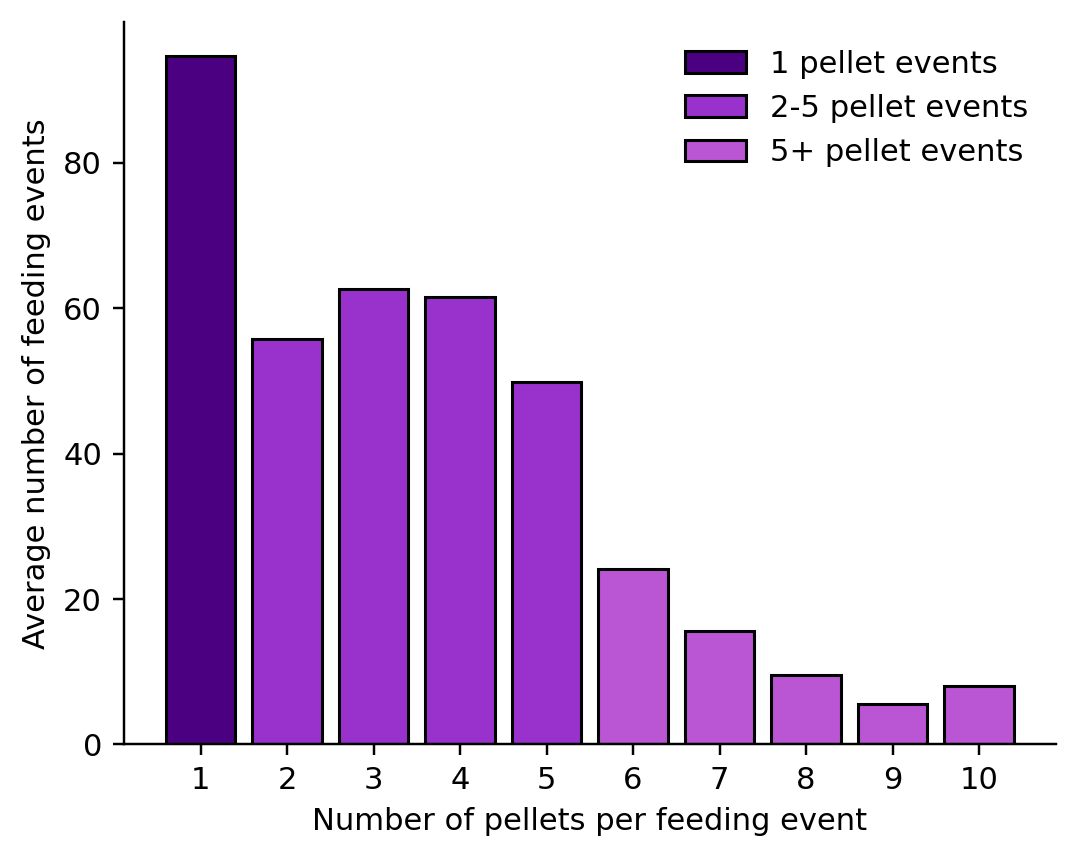

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def flatten_list(nested_list):
    """Helper function to flatten a list of lists into a single list."""
    return [item for sublist in nested_list for item in sublist]

def cluster_pellets_by_ipi(pellettimes, ipi_threshold=60):
    """
    Cluster pellet events based on inter-pellet interval (IPI).
    Parameters
    ----------
    pellettimes : list of timestamps (in seconds)
        Times when each pellet was taken.
    ipi_threshold : float
        Threshold for defining clusters based on IPI (in seconds). Default is 60 seconds.
    
    Returns
    -------
    clusters : list of lists
        Each sublist contains the timestamps of pellets within a cluster.
    """
    pellettimes = np.array(sorted(pellettimes))* 3600  # Convert from hours to seconds and sort

    IPIs = np.diff(pellettimes)  # Calculate time differences between consecutive pellets

    # Initialize clusters
    clusters = []
    current_cluster = [pellettimes[0]]  # Start with the first pellet

    for i, ipi in enumerate(IPIs):
        if ipi <= ipi_threshold:
            current_cluster.append(pellettimes[i + 1])
        else:
            clusters.append(current_cluster)
            current_cluster = [pellettimes[i + 1]]

    if current_cluster:
        clusters.append(current_cluster)

    return clusters

def get_cluster_size_distribution_for_mouse(pellettimes):
    """
    Get the cluster size distribution for a single mouse.
    Parameters
    ----------
    pellettimes : list of timestamps (in seconds)
        Times when each pellet was taken.
    
    Returns
    -------
    cluster_sizes : list
        The number of pellets in each cluster for this mouse.
    """
    clusters = cluster_pellets_by_ipi(pellettimes)
    cluster_sizes = [len(cluster) for cluster in clusters]
    return cluster_sizes

def average_cluster_sizes_across_mice(pellettimes_group, max_pellets_per_event=10):
    """
    Calculate the average cluster size distribution across multiple mice.
    Parameters
    ----------
    pellettimes_group : list of lists
        A list of timestamp lists for each mouse.
    max_pellets_per_event : int
        The maximum number of pellets per event to include in the analysis.
    
    Returns
    -------
    avg_cluster_sizes : list
        The average number of events for each cluster size (1 pellet, 2 pellets, etc.).
    """
    # Initialize the counts for each pellet size
    total_cluster_counts = np.zeros(max_pellets_per_event)

    # Loop over each mouse and calculate cluster size distribution
    for pellettimes in pellettimes_group:
        cluster_sizes = get_cluster_size_distribution_for_mouse(pellettimes)
        for size in cluster_sizes:
            if size <= max_pellets_per_event:
                total_cluster_counts[size - 1] += 1
            else:
                # If size exceeds max_pellets_per_event, add to the last bin
                total_cluster_counts[-1] += 1

    # Calculate the average cluster size distribution across mice
    avg_cluster_sizes = total_cluster_counts / len(pellettimes_group)
    
    return avg_cluster_sizes

def plot_average_cluster_size_distribution(avg_cluster_sizes, max_pellets_per_event=25, save_path=None):
    """
    Plot the average cluster size distribution across multiple mice with custom colors and optionally save the figure.
    Parameters
    ----------
    avg_cluster_sizes : list
        The average number of events for each cluster size (1 pellet, 2 pellets, etc.).
    max_pellets_per_event : int
        The maximum number of pellets per event included in the analysis.
    save_path : str or None
        The file path to save the figure. If None, the figure is not saved.
    """
    f, ax = plt.subplots(figsize=(5, 4), dpi=220)

    bins = np.arange(1, max_pellets_per_event + 1)

    # Define colors based on cluster sizes
    colors = []
    for size in bins:
        if size == 1:
            colors.append('indigo')  # 1-pellet events
        elif 2 <= size <= 5:
            colors.append('darkorchid')   # 2-5-pellet events
        else:
            colors.append('mediumorchid') # 5+ pellet events

    # Plot the bar chart with custom colors
    ax.bar(bins, avg_cluster_sizes, color=colors, edgecolor='black')

    ax.set_ylabel('Average number of feeding events', fontsize=10)
    ax.set_xlabel('Number of pellets per feeding event', fontsize=10)
    ax.set_xticks(bins)
    ax.set_title('', fontsize=18)

    # Add legend to explain the colors
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='indigo', edgecolor='black', label='1 pellet events'),
                       Patch(facecolor='darkorchid', edgecolor='black', label='2-5 pellet events'),
                       Patch(facecolor='mediumorchid', edgecolor='black', label='5+ pellet events')]
    ax.legend(handles=legend_elements, frameon=False, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.grid(False)
    plt.tight_layout()

    # Save the figure if a save path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=220)

    plt.show()

nrpr_male_selector = {"order": 1, "sex": "M"}
pellettimes_group = get_data_fields(mice, ["nr_timestamps"], nrpr_male_selector)  # Get the timestamps for each mouse

# Calculate the average cluster size distribution across mice
avg_cluster_sizes = average_cluster_sizes_across_mice(pellettimes_group, max_pellets_per_event=10)

# Plot the average distribution of cluster sizes with custom colors
plot_average_cluster_size_distribution(avg_cluster_sizes, max_pellets_per_event=10)


5 items in output dictionary


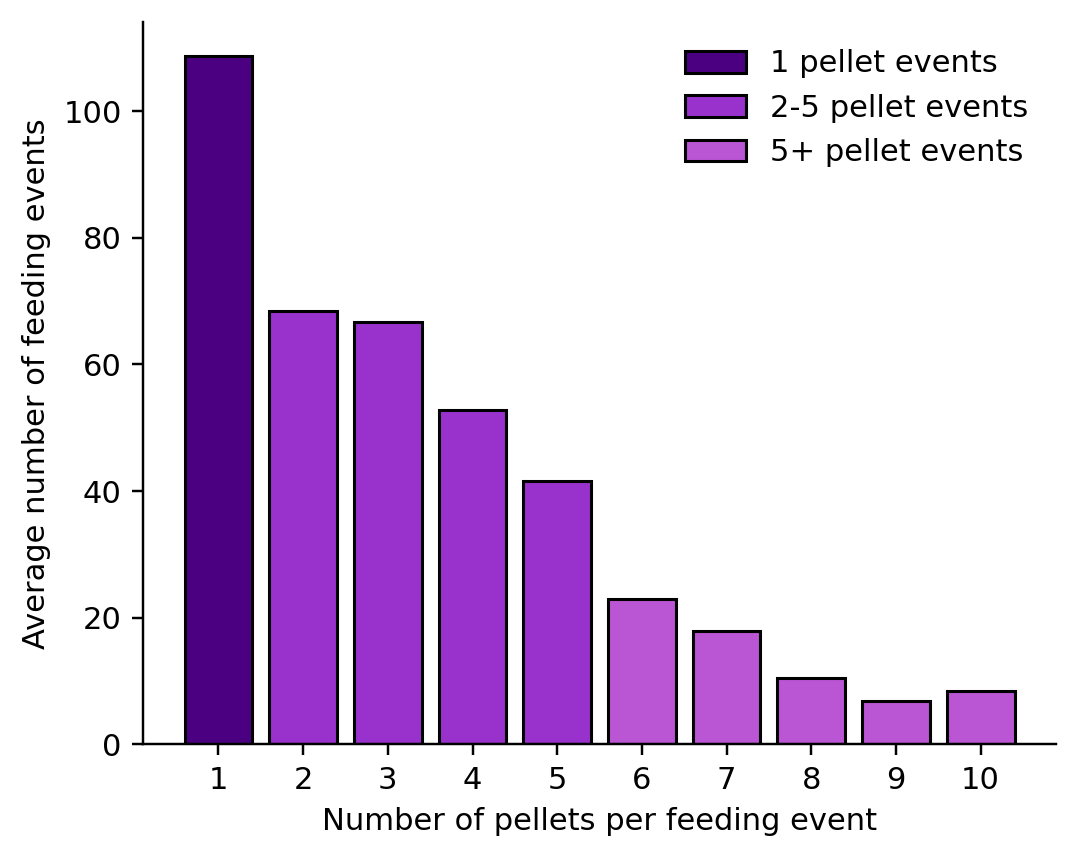

In [18]:

nrpr_female_selector = {"order": 1, "sex": "F"}
pellettimes_group_female = get_data_fields(mice, ["nr_timestamps"], nrpr_female_selector)  # Get timestamps for females

combined_pellettimes_group = pellettimes_group + pellettimes_group_female

combined_avg_cluster_sizes = average_cluster_sizes_across_mice(combined_pellettimes_group, max_pellets_per_event=10)

# Step 4: Plot the combined data
plot_average_cluster_size_distribution(combined_avg_cluster_sizes, max_pellets_per_event=10)
#, save_path= "../plots/NEW_MEAL_PLOTS/Cluster_size.png")
# Save the figure


In [19]:
# Show the combined average cluster sizes as output
print("Combined Average Cluster Sizes:")
for i, count in enumerate(combined_avg_cluster_sizes, start=1):
    print(f"Cluster Size {i}: {count:.2f} events")

Combined Average Cluster Sizes:
Cluster Size 1: 108.64 events
Cluster Size 2: 68.36 events
Cluster Size 3: 66.64 events
Cluster Size 4: 52.73 events
Cluster Size 5: 41.64 events
Cluster Size 6: 22.91 events
Cluster Size 7: 17.91 events
Cluster Size 8: 10.45 events
Cluster Size 9: 6.91 events
Cluster Size 10: 8.36 events


In [ ]:
def plot_average_cluster_size_distribution(avg_cluster_sizes, max_pellets_per_event=25, save_path=None):
    """
    Plot the average cluster size distribution across multiple mice with custom colors and optionally save the figure.
    Parameters
    ----------
    avg_cluster_sizes : list
        The average number of events for each cluster size (1 pellet, 2 pellets, etc.).
    max_pellets_per_event : int
        The maximum number of pellets per event included in the analysis.
    save_path : str or None
        The file path to save the figure. If None, the figure is not saved.
    """
    f, ax = plt.subplots(figsize=(5, 3), dpi=220)

    bins = np.arange(1, max_pellets_per_event + 1)

    # Define colors based on cluster sizes
    colors = []
    for size in bins:
        if size == 1:
            colors.append('skyblue')  # 1-pellet events
        elif 2 <= size <= 5:
            colors.append('deepskyblue')   # 2-5-pellet events
        else:
            colors.append('dodgerblue') # 5+ pellet events

    # Plot the bar chart with custom colors
    ax.bar(bins, avg_cluster_sizes, color=colors, edgecolor='black')

    ax.set_ylabel('Average number of feeding events', fontsize=10)
    ax.set_xlabel('Number of pellets per feeding event', fontsize=10)
    ax.set_xticks(bins)
    ax.set_title('', fontsize=18)

    # Add legend to explain the colors
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='skyblue', edgecolor='black', label='Single Pellet Events'),
                       Patch(facecolor='deepskyblue', edgecolor='black', label='2-5 Pellet Events'),
                       Patch(facecolor='dodgerblue', edgecolor='black', label='5+ Pellet Events')]
    ax.legend(handles=legend_elements, frameon=False, fontsize=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.grid(False)
    plt.tight_layout()


    if save_path:
        plt.savefig(save_path, bbox_inches='tight')

    plt.show()


In [7]:
def get_cluster_size_counts(cluster_sizes, max_pellets_per_event=25):
    sizes = np.arange(1, max_pellets_per_event + 1)
    counts = np.zeros_like(sizes, dtype=int)
    for size in cluster_sizes:
        if size <= max_pellets_per_event:
            counts[size - 1] += 1
        else:
            counts[-1] += 1
    return sizes, counts


In [8]:
def exponential_decay(x, a, b):
    return a * np.exp(-b * x)


In [9]:
from scipy.optimize import curve_fit

def fit_exponential_decay(sizes, counts):
    # Remove zeros to avoid log(0)
    mask = counts > 0
    sizes = sizes[mask]
    counts = counts[mask]

    if len(sizes) < 2:
        # Not enough data to fit
        return None, None

    # Log-transform the counts
    log_counts = np.log(counts)

    # Fit a linear function to the log-transformed data
    def linear_func(x, a, b):
        return a + b * x

    popt, pcov = curve_fit(linear_func, sizes, log_counts)
    a = np.exp(popt[0])
    b = -popt[1]
    return (a, b), pcov


In [2]:
import csv
from datetime import datetime
import numpy as np
import trompy as tp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Function to read FED events
def get_FEDevents(filename, eventname):
    formats = ['%Y-%m-%d %H:%M:%S', '%m/%d/%Y %H:%M:%S']
    
    try:
        file = open(filename)
    except FileNotFoundError:
        print(f"File not found: {filename}")
        return []
    
    csvreader = csv.reader(file)
    next(csvreader)  # Skip header
    rows = []
    for row in csvreader:
        rows.append(row)

    # Check if rows are empty
    if len(rows) == 0:
        print(f"No data found in file: {filename}")
        return []

    # Determine which format should be used
    try:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[0])
        date_format = formats[0]
    except ValueError:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[1])
        date_format = formats[1]

    timestamps = []
    for row in rows: 
        if row[7] == eventname:  # Check event column
            date_time_obj = datetime.strptime(row[0], date_format)
            timestamps.append(date_time_obj)

    if len(timestamps) == 0:
        print(f"No {eventname} events found in file: {filename}")
        return []

    t0 = rows[0][0]
    day = t0.split()[0] 
    lightson = day + " 07:00:00"
    refpoint = datetime.strptime(lightson, date_format)
    
    pellettimes = []
    for t in timestamps:
        Deltat = t - refpoint
        Deltatinseconds = Deltat.total_seconds()
        pellettimes.append(Deltatinseconds)

    return pellettimes

# Function to get a subset of data based on selectors
def get_data_subset(dictionary, selectors=None, verbose=True):
    if selectors is None or len(selectors) == 0:
        if verbose:
            print("{} items in output dictionary (no selectors applied)".format(len(dictionary.keys())))
        return dictionary.copy()

    output_dictionary = dictionary.copy()
    for key, value in selectors.items():
        for mouse_id in list(output_dictionary.keys()):
            try:
                mouse_value = output_dictionary[mouse_id][key]
                if isinstance(value, list):
                    if mouse_value not in value:
                        output_dictionary.pop(mouse_id)
                else:
                    if mouse_value != value:
                        output_dictionary.pop(mouse_id)
            except KeyError:
                pass

    if verbose:
        print("{} items in output dictionary after applying selectors".format(len(output_dictionary.keys())))

    return output_dictionary

# Function to get specific fields from the data
def get_data_fields(dictionary, fields, selectors):
    output_list = []
    reduced_dictionary = get_data_subset(dictionary, selectors)
    
    if len(reduced_dictionary.keys()) > 0:
        for field in fields:
            output_sublist = []
            try:
                for key in reduced_dictionary.keys():
                    output_sublist.append(reduced_dictionary[key][field])
            except KeyError:
                print("{} is not a key in selected dictionary".format(field))
                return
            output_list.append(output_sublist)
    else:
        print("No data in fields in selected dictionary")

    if len(output_list) == 1:
        output_list = output_list[0]
        
    return output_list

# Function to get meal, snack, and mega meal metrics
def get_meal_and_snack_metrics(pellettimes, meal_threshold=60):
    if not pellettimes:
        return (0, 0, 0, 0, 0, 0, 0, 0, [[0]*24]*7, [[0]*24]*7, [[0]*24]*7, [], [], [], 0, [], [])

    # Sort pellettimes in seconds
    pellettimes = np.array(sorted(pellettimes))
    IPIs = np.diff(pellettimes)
    meals = []
    snacks = []
    mega_meals = []
    IMIs = []
    current_event = [pellettimes[0]]

    # Hourly tracking for each day
    hourly_meals_per_day = [[0]*24 for _ in range(7)]
    hourly_snacks_per_day = [[0]*24 for _ in range(7)]
    hourly_mega_meals_per_day = [[0]*24 for _ in range(7)]

    for i, ipi in enumerate(IPIs):
        if ipi <= meal_threshold:
            current_event.append(pellettimes[i + 1])
        else:
            event_start_time = current_event[0]
            day_index = int(event_start_time // (24 * 3600))
            hour = int((event_start_time % (24 * 3600)) // 3600)
            if len(current_event) == 1:
                snacks.append(current_event)
                if day_index < 7:
                    hourly_snacks_per_day[day_index][hour] += 1
            elif 2 <= len(current_event) <= 4:
                meals.append(current_event)
                if day_index < 7:
                    hourly_meals_per_day[day_index][hour] += 1
            elif len(current_event) >= 5:
                mega_meals.append(current_event)
                if day_index < 7:
                    hourly_mega_meals_per_day[day_index][hour] += 1
            IMIs.append(ipi)
            current_event = [pellettimes[i + 1]]

    # Handle the last sequence
    if current_event:
        event_start_time = current_event[0]
        day_index = int(event_start_time // (24 * 3600))
        hour = int((event_start_time % (24 * 3600)) // 3600)
        if len(current_event) == 1:
            snacks.append(current_event)
            if day_index < 7:
                hourly_snacks_per_day[day_index][hour] += 1
        elif 2 <= len(current_event) <= 4:
            meals.append(current_event)
            if day_index < 7:
                hourly_meals_per_day[day_index][hour] += 1
        elif len(current_event) >= 5:
            mega_meals.append(current_event)
            if day_index < 7:
                hourly_mega_meals_per_day[day_index][hour] += 1

    nmeals = len(meals)
    nsnacks = len(snacks)
    n_mega_meals = len(mega_meals)

    total_pellets = len(pellettimes)
    mealsize = sum(len(meal) for meal in meals) / nmeals if nmeals else 0
    snack_size = sum(len(snack) for snack in snacks) / nsnacks if nsnacks else 0
    total_observation_period = (max(pellettimes) - min(pellettimes)) / 3600  # Convert to hours
    meal_frequency = nmeals / total_observation_period if total_observation_period > 0 else 0
    snack_frequency = nsnacks / total_observation_period if total_observation_period > 0 else 0
    mega_meal_frequency = n_mega_meals / total_observation_period if total_observation_period > 0 else 0
    average_mega_meal_size = sum(len(meal) for meal in mega_meals) / n_mega_meals if n_mega_meals else 0

    return (mealsize, snack_size, nmeals, meal_frequency, nsnacks, snack_frequency, 
            mega_meal_frequency, average_mega_meal_size, hourly_meals_per_day, 
            hourly_snacks_per_day, hourly_mega_meals_per_day, meals, snacks, mega_meals, n_mega_meals, IPIs, IMIs)

# Function to get events per day
def get_events_per_day(events, days=7):
    events_per_day = [0] * days
    for event_list in events:
        if len(event_list) > 0:
            event_day = int(event_list[0] // (24 * 3600))
            if event_day < days:
                events_per_day[event_day] += 1
    return events_per_day

# Function to calculate pellets per day
def get_pellets_per_day(timestamps, days=7):
    pellets_per_day = [0] * days
    for day in range(days):
        start_time = day * 24 * 3600
        end_time = (day + 1) * 24 * 3600
        pellets = [t for t in timestamps if (t >= start_time) and (t < end_time)]
        n_pellets = len(pellets)
        pellets_per_day[day] = n_pellets

    return pellets_per_day

# Function to cluster pellets by IPI
def cluster_pellets_by_ipi(pellettimes, ipi_threshold=60):
    pellettimes = np.array(sorted(pellettimes))  # Times in seconds
    IPIs = np.diff(pellettimes)
    clusters = []
    current_cluster = [pellettimes[0]]

    for i, ipi in enumerate(IPIs):
        if ipi <= ipi_threshold:
            current_cluster.append(pellettimes[i + 1])
        else:
            clusters.append(current_cluster)
            current_cluster = [pellettimes[i + 1]]

    if current_cluster:
        clusters.append(current_cluster)

    return clusters

# Function to get cluster size distribution for a mouse
def get_cluster_size_distribution_for_mouse(pellettimes):
    clusters = cluster_pellets_by_ipi(pellettimes)
    cluster_sizes = [len(cluster) for cluster in clusters]
    return cluster_sizes

# Function to get counts of cluster sizes
def get_cluster_size_counts(cluster_sizes, max_pellets_per_event=25):
    sizes = np.arange(1, max_pellets_per_event + 1)
    counts = np.zeros_like(sizes, dtype=int)
    for size in cluster_sizes:
        if size <= max_pellets_per_event:
            counts[size - 1] += 1
        else:
            counts[-1] += 1
    return sizes, counts

# Exponential decay function
def exponential_decay(x, a, b):
    return a * np.exp(-b * x)

# Function to fit exponential decay
def fit_exponential_decay(sizes, counts):
    # Remove zeros to avoid log(0)
    mask = counts > 0
    sizes = sizes[mask]
    counts = counts[mask]

    if len(sizes) < 2:
        # Not enough data to fit
        return None, None

    # Log-transform the counts
    log_counts = np.log(counts)

    # Fit a linear function to the log-transformed data
    def linear_func(x, a, b):
        return a + b * x

    popt, pcov = curve_fit(linear_func, sizes, log_counts)
    a = np.exp(popt[0])
    b = -popt[1]
    return (a, b), pcov

# Function to perform exponential decay fitting for all phases
def fit_exponential_decay_for_all_phases(mice, phases=['grain', 'pr', 'nr'], max_pellets_per_event=15):
    for mouse_id in mice:
        for phase in phases:
            pellettimes = mice[mouse_id].get(f"{phase}_timestamps", [])
            if not pellettimes:
                continue
            # Get cluster sizes
            cluster_sizes = get_cluster_size_distribution_for_mouse(pellettimes)
            # Get counts of each cluster size
            sizes, counts = get_cluster_size_counts(cluster_sizes, max_pellets_per_event)
            # Fit exponential decay
            params, pcov = fit_exponential_decay(sizes, counts)
            if params is not None:
                a, b = params
                mice[mouse_id][f'exp_fit_params_{phase}'] = {'a': a, 'b': b}
            else:
                print(f"Not enough data to fit for mouse {mouse_id} in {phase.upper()} phase")

# Function to save results to CSV
def save_results_to_csv(mice, filename='exponential_decay_results.csv'):
    # Prepare the data
    data_list = []
    for mouse_id, mouse_data in mice.items():
        order = mouse_data.get('order', 'NA')
        sex = mouse_data.get('sex', 'NA')
        for phase in ['grain', 'pr', 'nr']:
            exp_params = mouse_data.get(f'exp_fit_params_{phase}', None)
            if exp_params:
                a = exp_params['a']
                b = exp_params['b']
                data_list.append({
                    'mouse_id': mouse_id,
                    'order': order,
                    'sex': sex,
                    'diet_phase': phase.upper(),
                    'a': a,
                    'b': b
                })
    # Write to CSV
    with open(filename, mode='w', newline='') as csv_file:
        fieldnames = ['mouse_id', 'order', 'sex', 'diet_phase', 'a', 'b']
        writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
        writer.writeheader()
        for data in data_list:
            writer.writerow(data)
    print(f"Results saved to {filename}")

# Function to visualize the cluster size distribution and fit
def visualize_cluster_size_distribution(mouse_id, phase, mice, max_pellets_per_event=25):
    exp_params = mice[mouse_id].get(f'exp_fit_params_{phase}', None)
    if exp_params:
        a = exp_params['a']
        b = exp_params['b']
        pellettimes = mice[mouse_id].get(f"{phase}_timestamps", [])
        if not pellettimes:
            return
        # Get cluster sizes and counts
        cluster_sizes = get_cluster_size_distribution_for_mouse(pellettimes)
        sizes, counts = get_cluster_size_counts(cluster_sizes, max_pellets_per_event)
        # Plot
        plt.figure()
        plt.scatter(sizes, counts, label='Data')
        plt.plot(sizes, exponential_decay(sizes, a, b), label='Exponential Fit', color='red')
        plt.xlabel('Cluster Size (Number of Pellets per Event)')
        plt.ylabel('Counts')
        plt.title(f'Mouse {mouse_id} - {phase.upper()} Phase')
        plt.legend()
        plt.show()

# Load the metafile and process the data
metafile = "..\\src\\FEDProtein_METAFILE.xls"
rows, header = tp.metafilereader(metafile, sheetname="METAFILE")

mice = {}
for row in rows:
    mouse_id = row[1]
    if mouse_id not in mice.keys():
        mice[mouse_id] = {}
        mice[mouse_id]["sex"] = row[4]
        mice[mouse_id]["order"] = row[5]

for key in mice.keys():
    for row in rows:
        if row[1] == key and row[3] == "FF":
            filename = "..\\src\\data\\{}".format(row[0])
            if row[2] == "GRAIN":
                mice[key]["grain_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "PR":
                mice[key]["pr_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "NR":
                mice[key]["nr_timestamps"] = get_FEDevents(filename, "Pellet")
            else:
                print(row[2], "is not a valid type of pellet for", key)

# Add meal, snack, mega meal metrics, and IMI, IPI calculations to the dictionary
for key in mice.keys():
    grain_timestamps = mice[key].get("grain_timestamps", [])
    pr_timestamps = mice[key].get("pr_timestamps", [])
    nr_timestamps = mice[key].get("nr_timestamps", [])

    # Get metrics for GRAIN, PR, and NR phases
    grain_metrics = get_meal_and_snack_metrics(grain_timestamps)
    pr_metrics = get_meal_and_snack_metrics(pr_timestamps)
    nr_metrics = get_meal_and_snack_metrics(nr_timestamps)

    # GRAIN phase
    (
        mice[key]["grain_meal_size"],
        mice[key]["grain_snack_size"],
        mice[key]["grain_number_of_meals"],
        mice[key]["grain_meal_frequency"],
        mice[key]["grain_number_of_snacks"],
        mice[key]["grain_snack_frequency"],
        mice[key]["grain_mega_meal_frequency"],
        mice[key]["grain_mega_meal_size"],
        mice[key]["grain_hourly_meals"],
        mice[key]["grain_hourly_snacks"],
        mice[key]["grain_hourly_mega_meals"],
        grain_meals,
        grain_snacks,
        grain_mega_meals,
        mice[key]["grain_number_of_mega_meals"],
        mice[key]["grain_ipi"],
        mice[key]["grain_imi"]
    ) = grain_metrics

    # PR phase
    (
        mice[key]["pr_meal_size"],
        mice[key]["pr_snack_size"],
        mice[key]["pr_number_of_meals"],
        mice[key]["pr_meal_frequency"],
        mice[key]["pr_number_of_snacks"],
        mice[key]["pr_snack_frequency"],
        mice[key]["pr_mega_meal_frequency"],
        mice[key]["pr_mega_meal_size"],
        mice[key]["pr_hourly_meals"],
        mice[key]["pr_hourly_snacks"],
        mice[key]["pr_hourly_mega_meals"],
        pr_meals,
        pr_snacks,
        pr_mega_meals,
        mice[key]["pr_number_of_mega_meals"],
        mice[key]["pr_ipi"],
        mice[key]["pr_imi"]
    ) = pr_metrics

    # NR phase
    (
        mice[key]["nr_meal_size"],
        mice[key]["nr_snack_size"],
        mice[key]["nr_number_of_meals"],
        mice[key]["nr_meal_frequency"],
        mice[key]["nr_number_of_snacks"],
        mice[key]["nr_snack_frequency"],
        mice[key]["nr_mega_meal_frequency"],
        mice[key]["nr_mega_meal_size"],
        mice[key]["nr_hourly_meals"],
        mice[key]["nr_hourly_snacks"],
        mice[key]["nr_hourly_mega_meals"],
        nr_meals,
        nr_snacks,
        nr_mega_meals,
        mice[key]["nr_number_of_mega_meals"],
        mice[key]["nr_ipi"],
        mice[key]["nr_imi"]
    ) = nr_metrics

    # Events per day and pellets per day
    mice[key]["grain_meals_per_day"] = get_events_per_day(grain_meals, days=3)
    mice[key]["pr_meals_per_day"] = get_events_per_day(pr_meals, days=7)
    mice[key]["nr_meals_per_day"] = get_events_per_day(nr_meals, days=7)

    mice[key]["grain_snacks_per_day"] = get_events_per_day(grain_snacks, days=3)
    mice[key]["pr_snacks_per_day"] = get_events_per_day(pr_snacks, days=7)
    mice[key]["nr_snacks_per_day"] = get_events_per_day(nr_snacks, days=7)

    mice[key]["grain_mega_meals_per_day"] = get_events_per_day(grain_mega_meals, days=3)
    mice[key]["pr_mega_meals_per_day"] = get_events_per_day(pr_mega_meals, days=7)
    mice[key]["nr_mega_meals_per_day"] = get_events_per_day(nr_mega_meals, days=7)

    mice[key]["grain_pellets_per_day"] = get_pellets_per_day(mice[key]["grain_timestamps"], days=3)
    mice[key]["pr_pellets_per_day"] = get_pellets_per_day(mice[key]["pr_timestamps"], days=7)
    mice[key]["nr_pellets_per_day"] = get_pellets_per_day(mice[key]["nr_timestamps"], days=7)

# Combine events and pellets per day for the entire 17-day time course
for key in mice.keys():
    # Combine pellets per day
    mice[key]["all_pellets_per_day"] = (
        mice[key].get("grain_pellets_per_day", [0] * 3) +
        mice[key].get("pr_pellets_per_day", [0] * 7) +
        mice[key].get("nr_pellets_per_day", [0] * 7)
    )

    # Combine meals per day
    mice[key]["all_meals_per_day"] = (
        mice[key].get("grain_meals_per_day", [0] * 3) +
        mice[key].get("pr_meals_per_day", [0] * 7) +
        mice[key].get("nr_meals_per_day", [0] * 7)
    )

    # Combine snacks per day
    mice[key]["all_snacks_per_day"] = (
        mice[key].get("grain_snacks_per_day", [0] * 3) +
        mice[key].get("pr_snacks_per_day", [0] * 7) +
        mice[key].get("nr_snacks_per_day", [0] * 7)
    )

    # Combine mega meals per day
    mice[key]["all_mega_meals_per_day"] = (
        mice[key].get("grain_mega_meals_per_day", [0] * 3) +
        mice[key].get("pr_mega_meals_per_day", [0] * 7) +
        mice[key].get("nr_mega_meals_per_day", [0] * 7)
    )






# Perform exponential decay fitting for all mice and all phases
fit_exponential_decay_for_all_phases(mice)

# # Save the results to a CSV file
#save_results_to_csv(mice, filename='../results/EXPO/exponential_decay_results_UPDATED.csv')




Number of mice selected: 6


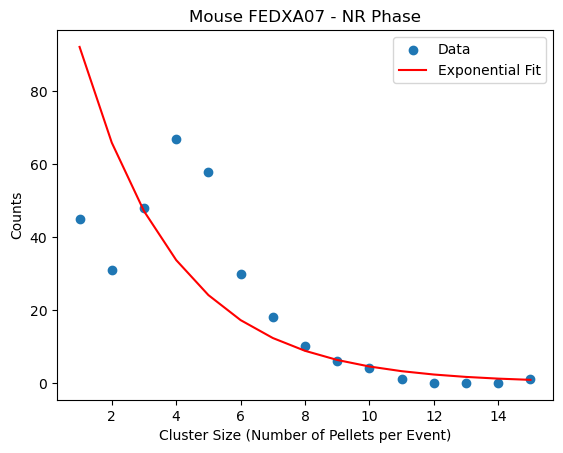

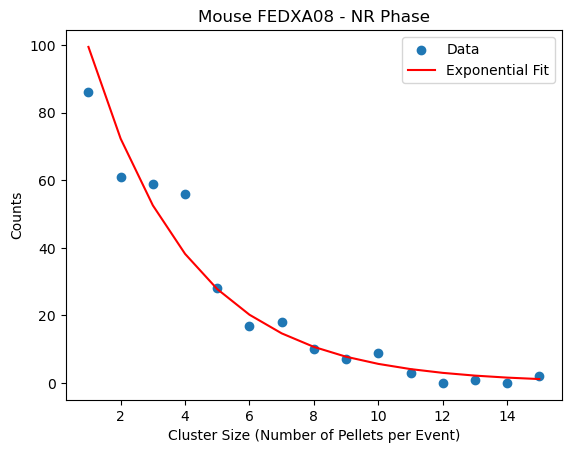

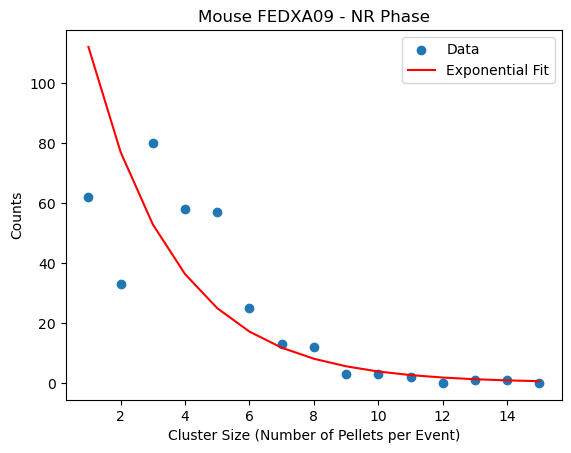

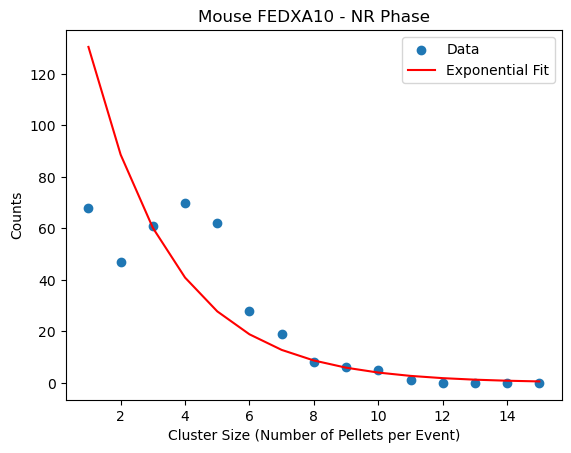

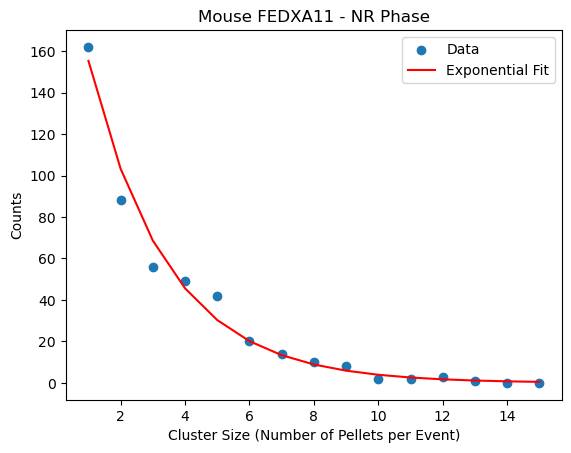

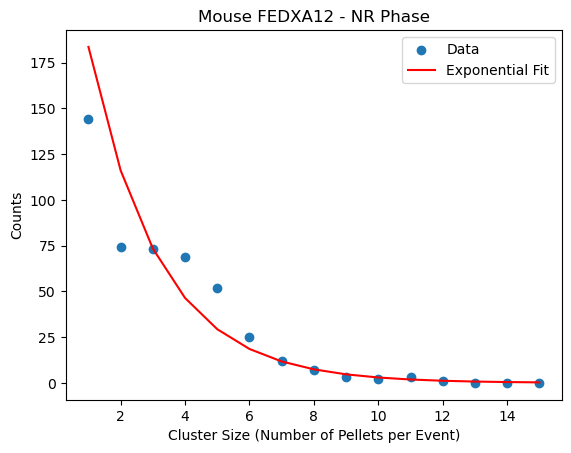

In [3]:
# Function to visualize cluster size distribution for selected mice
def visualize_cluster_size_distribution_selected(mice, selectors, phase='nr', max_pellets_per_event=15, save_plots=False):
    # Get the list of mice IDs that match the selectors
    selected_mice = get_data_subset(mice, selectors, verbose=False)
    print(f"Number of mice selected: {len(selected_mice)}")
    for mouse_id in selected_mice:
        exp_params = mice[mouse_id].get(f'exp_fit_params_{phase}', None)
        if exp_params:
            a = exp_params['a']
            b = exp_params['b']
            pellettimes = mice[mouse_id].get(f"{phase}_timestamps", [])
            if not pellettimes:
                continue
            # Get cluster sizes and counts
            cluster_sizes = get_cluster_size_distribution_for_mouse(pellettimes)
            sizes, counts = get_cluster_size_counts(cluster_sizes, max_pellets_per_event)
            # Plot
            plt.figure()
            plt.scatter(sizes, counts, label='Data')
            plt.plot(sizes, exponential_decay(sizes, a, b), label='Exponential Fit', color='red')
            plt.xlabel('Cluster Size (Number of Pellets per Event)')
            plt.ylabel('Counts')
            plt.title(f'Mouse {mouse_id} - NR Phase')
            plt.legend()
            if save_plots:
                # Save the plot to a file
                filename = f"Mouse_{mouse_id}_NR_Cluster_Size_Distribution.png"
                plt.savefig(filename)
                plt.close()
            else:
                # Display the plot
                plt.show()
        else:
            print(f"No exponential fit parameters for mouse {mouse_id} in NR phase.")

# Define the selectors for male mice in Order 1
selectors = {'sex': 'M', 'order': 1}

# Call the function to visualize the cluster size distributions
visualize_cluster_size_distribution_selected(mice, selectors, phase='nr', save_plots=False)


In [4]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import ttest_ind, pearsonr
import pandas as pd



def get_data_subset(dictionary, selectors, verbose=True):
    """
    Select a subset of mice based on specified criteria.
    
    Parameters
    ----------
    dictionary : dict
        Dictionary containing data for each mouse.
    selectors : dict
        Dictionary of selection criteria (e.g., {"sex": "M", "order": 1}).
    verbose : bool
        If True, prints the number of selected mice.
    
    Returns
    -------
    output_dictionary : dict
        Dictionary of selected mice.
    """
    output_dictionary = dictionary.copy()
    for key, value in selectors.items():
        for mouse_id in list(dictionary.keys()):
            try:
                if isinstance(value, list):
                    if output_dictionary[mouse_id][key] not in value:
                        del output_dictionary[mouse_id]
                else:
                    if output_dictionary[mouse_id][key] != value:
                        del output_dictionary[mouse_id]
            except KeyError:
                # If the key doesn't exist for a mouse, exclude it
                del output_dictionary[mouse_id]
    if verbose:
        print(f"{len(output_dictionary.keys())} mice selected based on selectors.")
    return output_dictionary

def cluster_pellets_by_ipi(pellettimes, ipi_threshold=60):
    """
    Cluster pellet events based on inter-pellet interval (IPI).
    
    Parameters
    ----------
    pellettimes : list of timestamps (in seconds)
        Times when each pellet was taken.
    ipi_threshold : float
        Threshold for defining clusters based on IPI (in seconds). Default is 60 seconds.
    
    Returns
    -------
    clusters : list of lists
        Each sublist contains the timestamps of pellets within a cluster.
    """
    if not pellettimes:
        return []
    
    pellettimes_sorted = sorted(pellettimes)
    clusters = []
    current_cluster = [pellettimes_sorted[0]]
    
    for i in range(1, len(pellettimes_sorted)):
        ipi = pellettimes_sorted[i] - pellettimes_sorted[i - 1]
        if ipi <= ipi_threshold:
            current_cluster.append(pellettimes_sorted[i])
        else:
            clusters.append(current_cluster)
            current_cluster = [pellettimes_sorted[i]]
    clusters.append(current_cluster)  # Add the last cluster
    
    return clusters

def get_cluster_size_distribution_for_mouse(pellettimes):
    """
    Get the cluster size distribution for a single mouse.
    
    Parameters
    ----------
    pellettimes : list of timestamps (in seconds)
        Times when each pellet was taken.
    
    Returns
    -------
    cluster_sizes : list
        The number of pellets in each cluster for this mouse.
    """
    clusters = cluster_pellets_by_ipi(pellettimes)
    cluster_sizes = [len(cluster) for cluster in clusters]
    return cluster_sizes

def get_combined_cluster_sizes(mice, selectors, phase='nr'):
    """
    Collect cluster sizes for each selected mouse.
    
    Parameters
    ----------
    mice : dict
        Dictionary containing data for each mouse.
    selectors : dict
        Dictionary of selection criteria.
    phase : str
        The dietary phase to analyze (e.g., 'nr').
    
    Returns
    -------
    combined_cluster_sizes : list of lists
        Each sublist contains cluster sizes for one mouse.
    """
    selected_mice = get_data_subset(mice, selectors, verbose=False)
    num_mice = len(selected_mice)
    print(f"Number of mice selected: {num_mice}")
    if num_mice == 0:
        print("No mice match the selectors.")
        return []
    combined_cluster_sizes = []
    for mouse_id, data in selected_mice.items():
        pellettimes = data.get(f"{phase}_timestamps", [])
        if not pellettimes:
            continue
        cluster_sizes = get_cluster_size_distribution_for_mouse(pellettimes)
        combined_cluster_sizes.append(cluster_sizes)
    return combined_cluster_sizes

def average_cluster_sizes_across_mice(pellettimes_group, max_pellets_per_event=25):
    """
    Calculate the average cluster size distribution across multiple mice.
    
    Parameters
    ----------
    pellettimes_group : list of lists
        A list of cluster size lists for each mouse.
    max_pellets_per_event : int
        The maximum number of pellets per event to include in the analysis.
    
    Returns
    -------
    avg_cluster_sizes : numpy array
        The average number of events for each cluster size (1 pellet, 2 pellets, etc.).
    """
    if not pellettimes_group:
        return np.zeros(max_pellets_per_event)
    
    total_cluster_counts = np.zeros(max_pellets_per_event)
    num_mice = len(pellettimes_group)
    
    for cluster_sizes in pellettimes_group:
        for size in cluster_sizes:
            if size <= max_pellets_per_event:
                total_cluster_counts[size - 1] += 1
            else:
                total_cluster_counts[-1] += 1  # Add to the last bin if exceeds
    
    avg_cluster_sizes = total_cluster_counts / num_mice
    return avg_cluster_sizes

def exponential_decay(x, a, b):
    """
    Exponential decay function.
    
    Parameters
    ----------
    x : array-like
        Independent variable.
    a : float
        Scale parameter.
    b : float
        Decay rate parameter.
    
    Returns
    -------
    y : array-like
        Dependent variable.
    """
    return a * np.exp(-b * x)

def fit_exponential_decay(sizes, counts):
    """
    Fit an exponential decay model to the data.
    
    Parameters
    ----------
    sizes : array-like
        Cluster sizes.
    counts : array-like
        Counts corresponding to each cluster size.
    
    Returns
    -------
    popt : tuple or None
        Optimal values for the parameters (a, b). None if fit fails.
    pcov : 2D array or None
        The estimated covariance of popt. None if fit fails.
    """
    # Remove zeros to avoid log(0)
    mask = counts > 0
    sizes = sizes[mask]
    counts = counts[mask]

    if len(sizes) < 2:
        # Not enough data to fit
        return None, None

    # Fit exponential decay
    try:
        popt, pcov = curve_fit(exponential_decay, sizes, counts, p0=(max(counts), 0.1))
        return popt, pcov
    except RuntimeError:
        return None, None

def get_cluster_size_counts(cluster_sizes, max_pellets_per_event=25):
    """
    Get counts for each cluster size.
    
    Parameters
    ----------
    cluster_sizes : list
        List of cluster sizes.
    max_pellets_per_event : int
        Maximum number of pellets per event.
    
    Returns
    -------
    sizes : numpy array
        Array of cluster sizes.
    counts : numpy array
        Array of counts corresponding to each cluster size.
    """
    sizes = np.arange(1, max_pellets_per_event + 1)
    counts = np.zeros_like(sizes, dtype=int)
    for size in cluster_sizes:
        if size <= max_pellets_per_event:
            counts[size - 1] += 1
        else:
            counts[-1] += 1
    return sizes, counts


In [5]:
def visualize_average_cluster_size_distribution(mice, selectors, phase='nr', max_pellets_per_event=25, save_plot=False):
    """
    Visualize the average cluster size distribution for selected mice.
    
    Parameters
    ----------
    mice : dict
        Dictionary containing data for each mouse.
    selectors : dict
        Dictionary of selection criteria (e.g., {"sex": ["M", "F"], "order": 1}).
    phase : str
        The dietary phase to analyze (e.g., 'nr').
    max_pellets_per_event : int
        The maximum number of pellets per event to include in the analysis.
    save_plot : bool
        If True, saves the plot as a PNG file. Otherwise, displays the plot.
    """
    # Step 1: Collect combined cluster sizes
    combined_cluster_sizes = get_combined_cluster_sizes(mice, selectors, phase=phase)
    
    if not combined_cluster_sizes:
        print("No cluster size data available for the selected mice.")
        return
    
    # Step 2: Compute average cluster size distribution across mice
    avg_cluster_sizes = average_cluster_sizes_across_mice(combined_cluster_sizes, max_pellets_per_event=max_pellets_per_event)
    
    # Step 3: Define cluster sizes
    sizes = np.arange(1, max_pellets_per_event + 1)
    counts = avg_cluster_sizes  # Average counts per cluster size
    
    # Optional: Print average cluster sizes for verification
    # print(f"Average Cluster Sizes: {avg_cluster_sizes}")
    
    # Step 4: Fit exponential decay model to average counts
    params, pcov = fit_exponential_decay(sizes, counts)
    if params is not None:
        a, b = params
        print(f"Fitted parameters: a={a:.2f}, b={b:.2f}")
    
        # Step 5: Remove zeros to avoid plotting issues
        mask = counts > 0
        sizes_plot = sizes[mask]
        counts_plot = counts[mask]
    
        # Step 6: Plot the average cluster size distribution and exponential decay fit
        plt.figure(figsize=(10, 6))
        plt.scatter(sizes_plot, counts_plot, label='Pellets', color='purple')
        plt.plot(sizes_plot, exponential_decay(sizes_plot, a, b), label='Exponential Fit', color='black')
        plt.xlabel('Number of pellets per event', fontsize=14)
        plt.ylabel('Number of feeding events', fontsize=14)
        plt.title(f'Average distribution of pellet cluster sizes - Order 1 on {phase.upper()} Diet', fontsize=16)
        plt.legend()
        plt.grid(False)
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        
        if save_plot:
            # Save the plot to a file
            filename = f"Average_Order1_{phase.upper()}_Cluster_Size_Distribution.png"
            plt.savefig(filename)
            plt.close()
            print(f"Plot saved as {filename}")
        else:
            # Display the plot
            plt.show()
    else:
        print("Not enough data to fit the exponential decay model.")


Number of mice selected: 11
Fitted parameters: a=142.74, b=0.29


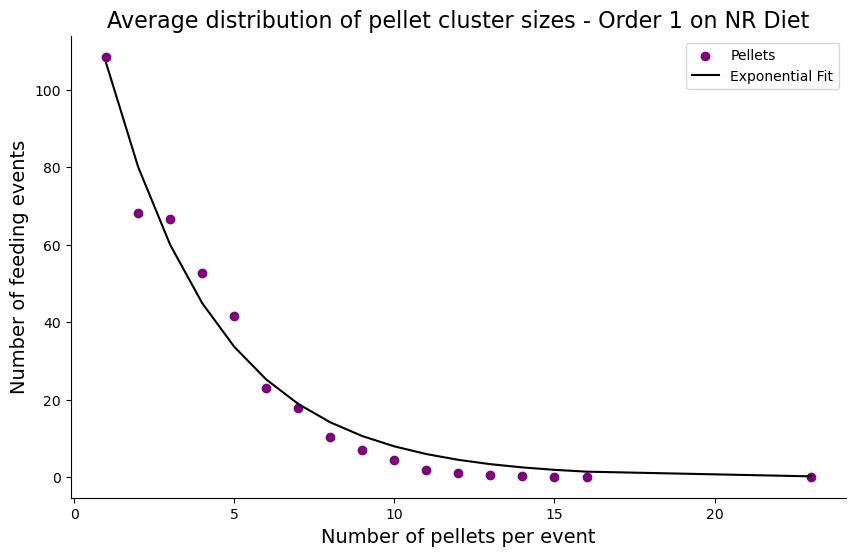

In [6]:
# Define the selectors for both male and female mice in Order 1
selectors = {'sex': ['M', 'F'], 'order': 1}

# Call the function to visualize the average cluster size distribution
visualize_average_cluster_size_distribution(
    mice=mice, 
    selectors=selectors, 
    phase='nr', 
    max_pellets_per_event=25, 
    save_plot=False  # Set to True if you want to save the plot
)


Number of mice selected: 12
Fitted parameters: a=350.96, b=0.45


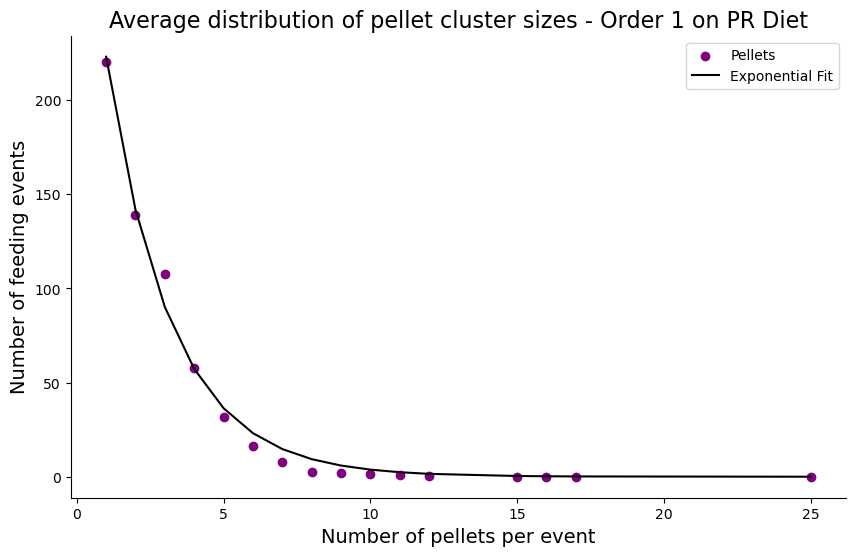

In [7]:
# Define the selectors for both male and female mice in Order 1
selectors = {'sex': ['M', 'F'], 'order': 2}

# Call the function to visualize the average cluster size distribution
visualize_average_cluster_size_distribution(
    mice=mice, 
    selectors=selectors, 
    phase='pr', 
    max_pellets_per_event=25, 
    save_plot=False  # Set to True if you want to save the plot
)


In [8]:
def visualize_average_cluster_size_distribution(mice, selectors, phase='nr', max_pellets_per_event=25, save_plot=False):
    """
    Visualize the average cluster size distribution for selected mice with a gradient exponential fit curve.
    
    Parameters
    ----------
    mice : dict
        Dictionary containing data for each mouse.
    selectors : dict
        Dictionary of selection criteria (e.g., {"sex": ["M", "F"], "order": 1}).
    phase : str
        The dietary phase to analyze (e.g., 'nr').
    max_pellets_per_event : int
        The maximum number of pellets per event to include in the analysis.
    save_plot : bool
        If True, saves the plot as a PNG file. Otherwise, displays the plot.
    """
    # Step 1: Collect combined cluster sizes
    combined_cluster_sizes = get_combined_cluster_sizes(mice, selectors, phase=phase)
    
    if not combined_cluster_sizes:
        print("No cluster size data available for the selected mice.")
        return
    
    # Step 2: Compute average cluster size distribution across mice
    avg_cluster_sizes = average_cluster_sizes_across_mice(combined_cluster_sizes, max_pellets_per_event=max_pellets_per_event)
    
    # Step 3: Define cluster sizes
    sizes = np.arange(1, max_pellets_per_event + 1)
    counts = avg_cluster_sizes  # Average counts per cluster size
    
    # Step 4: Fit exponential decay model to average counts
    params, pcov = fit_exponential_decay(sizes, counts)
    if params is not None:
        a, b = params
        print(f"Fitted parameters: a={a:.2f}, b={b:.2f}")
    
        # Step 5: Remove zeros to avoid plotting issues
        mask = counts > 0
        sizes_plot = sizes[mask]
        counts_plot = counts[mask]
    
        # Step 6: Generate a smooth exponential decay curve
        x_fit = np.linspace(sizes_plot.min(), sizes_plot.max(), 500)
        y_fit = exponential_decay(x_fit, a, b)
    
        # Normalize y_fit for alpha scaling (0 to 1)
        y_normalized = (y_fit - y_fit.min()) / (y_fit.max() - y_fit.min())
    
        # Step 7: Plot the average cluster size distribution
        plt.figure(figsize=(10, 6))
        plt.scatter(sizes_plot, counts_plot, label='Average Data', color='purple')
        
        # Step 8: Plot the exponential fit curve with gradient alpha
        for i in range(len(x_fit) - 1):
            # Calculate alpha based on y-value; higher y -> higher alpha
            alpha = y_normalized[i]
            plt.plot(x_fit[i:i+2], y_fit[i:i+2], color='black', alpha=alpha, linewidth=2)
        
        # Optional: Enhance the plot with annotations
        # Calculate R-squared for goodness of fit
        residuals = counts_plot - exponential_decay(sizes_plot, a, b)
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((counts_plot - np.mean(counts_plot))**2)
        r_squared = 1 - (ss_res / ss_tot)
        print(f"R-squared: {r_squared:.4f}")
        
        # Add annotations for parameters and R-squared
        plt.annotate(f'a = {a:.2f}\nb = {b:.2f}\nR² = {r_squared:.4f}', 
                     xy=(0.05, 0.95), xycoords='axes fraction',
                     fontsize=12, backgroundcolor='white',
                     verticalalignment='top')
        
        # Finalize the plot
        plt.xlabel('Cluster Size (Number of Pellets per Event)', fontsize=14)
        plt.ylabel('Average Counts', fontsize=14)
        plt.title(f'Average Cluster Size Distribution - Order 1 on {phase.upper()} Diet', fontsize=16)
        plt.legend()
        plt.grid(False)
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        
        if save_plot:
            # Save the plot to a file
            filename = f"Average_Order1_{phase.upper()}_Cluster_Size_Distribution.png"
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            plt.close()
            print(f"Plot saved as {filename}")
        else:
            # Display the plot
            plt.show()
    else:
        print("Not enough data to fit the exponential decay model.")


Number of mice selected: 11
Fitted parameters: a=142.74, b=0.29
R-squared: 0.9760


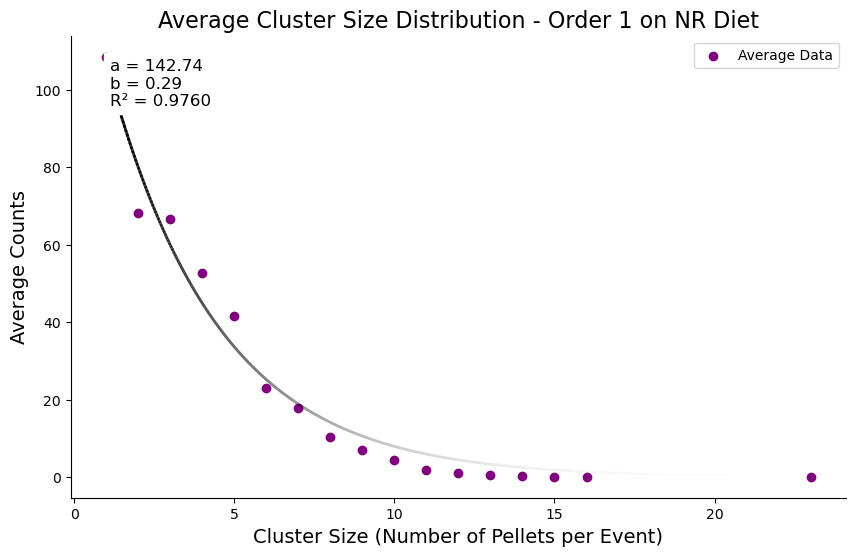

In [9]:
# Define the selectors for both male and female mice in Order 1
selectors = {'sex': ['M', 'F'], 'order': 1}

# Call the function to visualize the average cluster size distribution
visualize_average_cluster_size_distribution(
    mice=mice, 
    selectors=selectors, 
    phase='nr', 
    max_pellets_per_event=25, 
    save_plot=False  # Set to True to save the plot as a PNG file
)


Number of mice selected: 11
Fitted parameters: a=139.55, b=0.28
R-squared: 0.9668


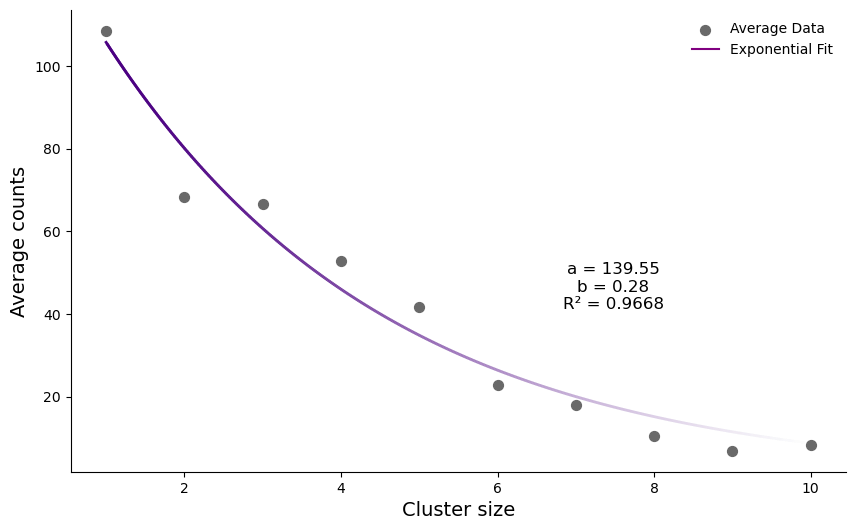

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D  # For proxy artist in legend

def visualize_average_cluster_size_distribution(mice, selectors, phase='nr', max_pellets_per_event=25, save_plot=False, file_path=None):
    """
    Visualize the average cluster size distribution for selected mice with a gradient exponential fit curve.
    
    Parameters
    ----------
    mice : dict
        Dictionary containing data for each mouse.
    selectors : dict
        Dictionary of selection criteria (e.g., {"sex": ["M", "F"], "order": 1}).
    phase : str
        The dietary phase to analyze (e.g., 'nr').
    max_pellets_per_event : int
        The maximum number of pellets per event to include in the analysis.
    save_plot : bool
        If True, saves the plot as a PNG file to the specified file_path. Otherwise, displays the plot.
    file_path : str
        The full file path for saving the plot. Required if save_plot is True.
    """
    # Step 1: Collect combined cluster sizes
    combined_cluster_sizes = get_combined_cluster_sizes(mice, selectors, phase=phase)
    
    if not combined_cluster_sizes:
        print("No cluster size data available for the selected mice.")
        return
    
    # Step 2: Compute average cluster size distribution across mice
    avg_cluster_sizes = average_cluster_sizes_across_mice(combined_cluster_sizes, max_pellets_per_event=max_pellets_per_event)
    
    # Step 3: Define cluster sizes
    sizes = np.arange(1, max_pellets_per_event + 1)
    counts = avg_cluster_sizes  # Average counts per cluster size
    
    # Step 4: Fit exponential decay model to average counts
    params, pcov = fit_exponential_decay(sizes, counts)
    if params is not None:
        a, b = params
        print(f"Fitted parameters: a={a:.2f}, b={b:.2f}")
    
        # Step 5: Remove zeros to avoid plotting issues
        mask = counts > 0
        sizes_plot = sizes[mask]
        counts_plot = counts[mask]
    
        # Step 6: Generate a smooth exponential decay curve
        x_fit = np.linspace(sizes_plot.min(), sizes_plot.max(), 500)
        y_fit = exponential_decay(x_fit, a, b)
    
        # Normalize y_fit for alpha scaling (0 to 1)
        y_normalized = (y_fit - y_fit.min()) / (y_fit.max() - y_fit.min())
    
        # Step 7: Plot the average cluster size distribution
        plt.figure(figsize=(10, 6))
        scatter = plt.scatter(sizes_plot, counts_plot, label='Average Data', color='dimgray', s=50)
        
        # Step 8: Plot the exponential fit curve with gradient alpha
        for i in range(len(x_fit) - 1):
            # Calculate alpha based on y-value; higher y -> higher alpha
            alpha = y_normalized[i]
            plt.plot(x_fit[i:i+2], y_fit[i:i+2], color='indigo', alpha=alpha, linewidth=2)
        
        # Step 9: Calculate R-squared for goodness of fit
        residuals = counts_plot - exponential_decay(sizes_plot, a, b)
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((counts_plot - np.mean(counts_plot))**2)
        r_squared = 1 - (ss_res / ss_tot)
        print(f"R-squared: {r_squared:.4f}")
        
        # Step 10: Add annotations for parameters and R-squared
        plt.annotate(f'a = {a:.2f}\nb = {b:.2f}\nR² = {r_squared:.4f}', 
                     xy=(0.7, 0.4), xycoords='axes fraction',
                     fontsize=12, backgroundcolor='white',
                     horizontalalignment='center',
                     verticalalignment='center')
        
        # Step 11: Create a proxy artist for the exponential fit to include in the legend
        proxy_line = Line2D([], [], color='purple', label='Exponential Fit')
        
        # Step 12: Finalize the plot
        plt.xlabel('Cluster size', fontsize=14)
        plt.ylabel('Average counts', fontsize=14)
        # plt.title(f'{phase.upper()} Average Cluster Size Distribution', fontsize=16)
        
        # Update the legend to include both scatter and fit
        plt.legend(handles=[scatter, proxy_line], frameon=False)
        
        plt.grid(False)
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        
        if save_plot:
            if file_path is None:
                raise ValueError("file_path must be specified if save_plot is True.")
            # Save the plot to a file
            plt.savefig(file_path, dpi=300, bbox_inches='tight')
            plt.close()
            print(f"Plot saved at {file_path}")
        else:
            # Display the plot
            plt.show()
    else:
        print("Not enough data to fit the exponential decay model.")

# Example usage:
selectors = {'sex': ['M', 'F'], 'order': 1}

# File path for saving the plot
#file_path = "..//plots/NEW_MEAL_PLOTS//average_cluster_size_distribution.png"

# Call the function
visualize_average_cluster_size_distribution(
    mice=mice, 
    selectors=selectors, 
    phase='nr', 
    max_pellets_per_event=10, 
    # save_plot=False,  # Save the plot
    # file_path=file_path  # Specify where to save the plot
)



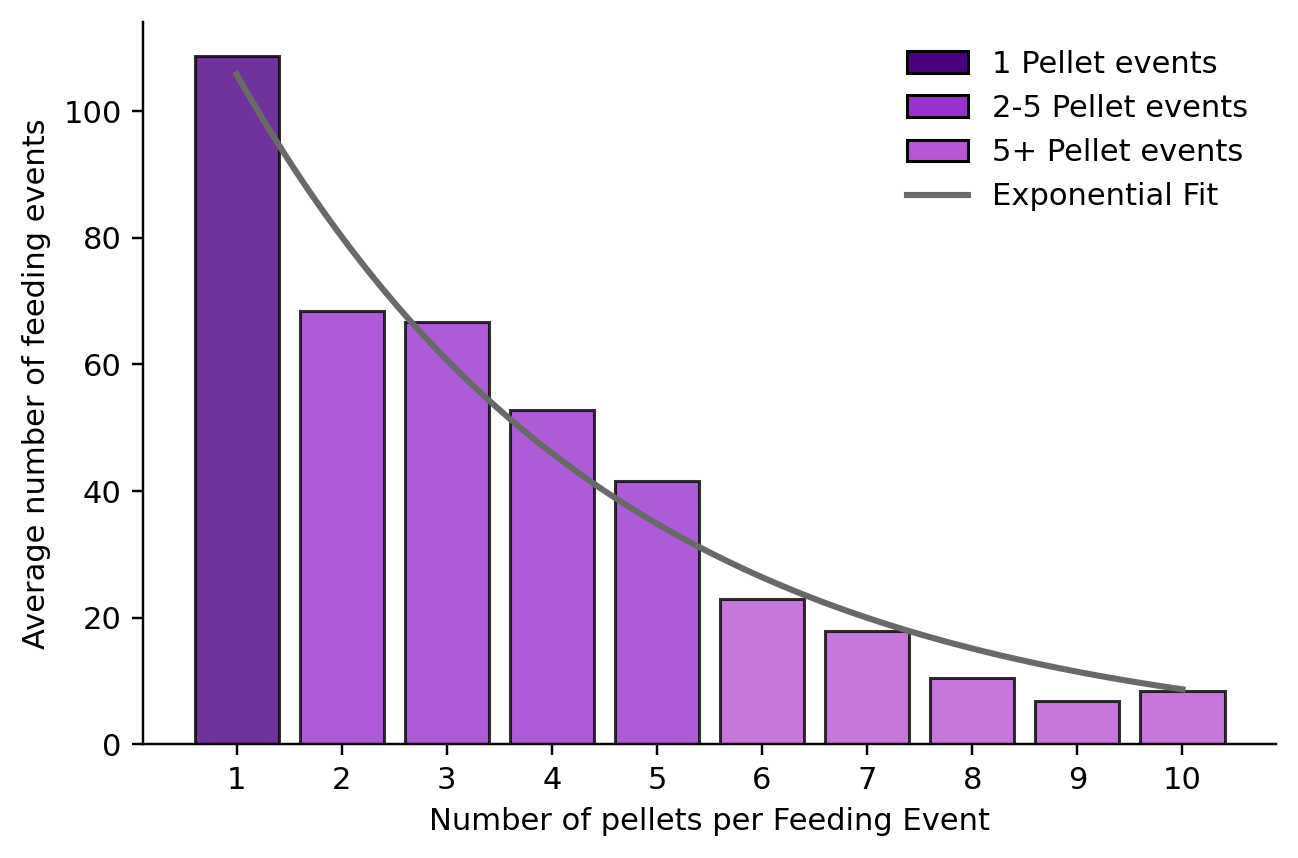

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.patches import Patch

# Define the exponential decay function
def exponential_decay(x, a, b):
    return a * np.exp(-b * x)

# Use your actual data from the computed cluster size distribution
sizes = np.arange(1, len(combined_avg_cluster_sizes) + 1)
avg_cluster_sizes = np.array(combined_avg_cluster_sizes)  # Your real data

# Fit the exponential curve to the actual data
params, _ = curve_fit(exponential_decay, sizes, avg_cluster_sizes, p0=(50, 0.2))

# Extract parameters for plotting
a, b = params

# Generate smooth curve for the exponential fit
x_fit = np.linspace(1, len(combined_avg_cluster_sizes), 100)
y_fit = exponential_decay(x_fit, a, b)

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 4), dpi=220)

# Define colors for bars based on pellet clusters
colors = ['indigo' if size == 1 else 'darkorchid' if 2 <= size <= 5 else 'mediumorchid' for size in sizes]

# Plot the bar chart with your actual data
ax.bar(sizes, avg_cluster_sizes, color=colors, edgecolor='black', alpha=0.8, label="Average Cluster Size")

# Overlay the exponential fit curve
ax.plot(x_fit, y_fit, color='dimgray', linestyle='solid', linewidth=2, label="Exponential Fit")

# Labels and formatting
ax.set_xlabel('Number of pellets per Feeding Event', fontsize=10)
ax.set_ylabel('Average number of feeding events', fontsize=10)
ax.set_xticks(sizes)
ax.set_title('', fontsize=12)

# Legend setup
legend_elements = [
    Patch(facecolor='indigo', edgecolor='black', label='1 Pellet events'),
    Patch(facecolor='darkorchid', edgecolor='black', label='2-5 Pellet events'),
    Patch(facecolor='mediumorchid', edgecolor='black', label='5+ Pellet events')
]
ax.legend(handles=legend_elements + [plt.Line2D([0], [0], color='dimgray', linestyle='solid', linewidth=2, label="Exponential Fit")], frameon=False, fontsize=10)

# Remove unnecessary spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Display plot
plt.tight_layout()
plt.show()


# here the probability of forming new clusters


Conditional Probabilities P(x+1 | x) for cluster sizes 1-10 (NR Phase, Order 1 Mice):
P(2 | 1) = 0.6293
P(3 | 2) = 0.9747
P(4 | 3) = 0.7913
P(5 | 4) = 0.7897
P(6 | 5) = 0.5502
P(7 | 6) = 0.7817
P(8 | 7) = 0.5838
P(9 | 8) = 0.6609
P(10 | 9) = 0.6316


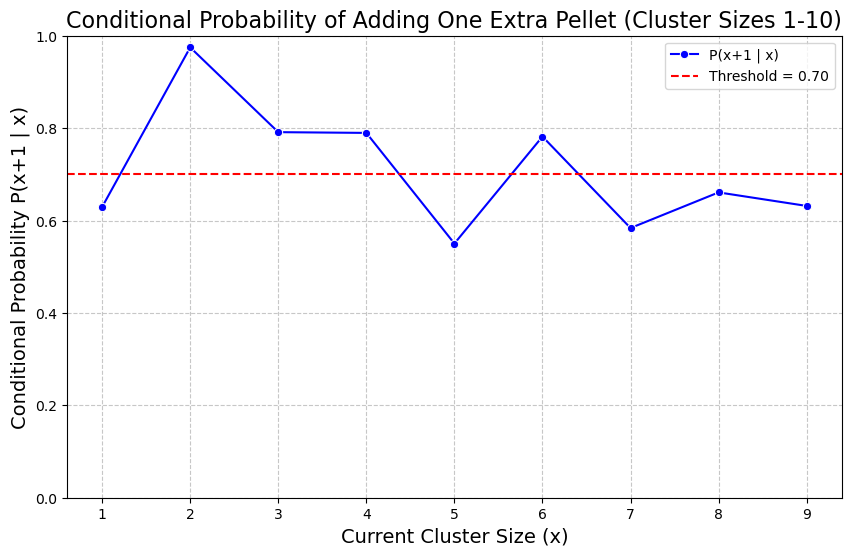

Determined Threshold based on Maximum Gap Method: 0.5502


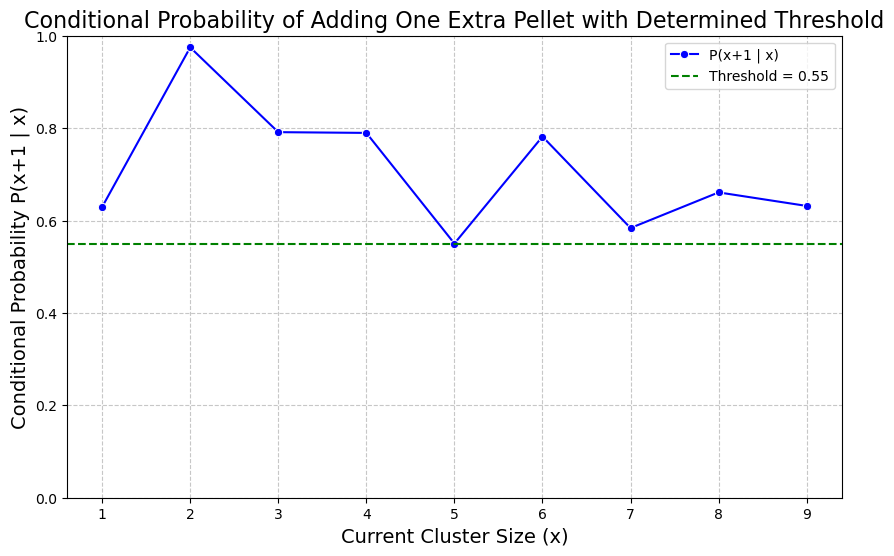


Mouse FEDXA07 - Phase NR with Threshold 0.55:
  Refined Meals: 272
  Refined Snacks: 45
  Refined Mega Meals: 2

Mouse FEDXA08 - Phase NR with Threshold 0.55:
  Refined Meals: 265
  Refined Snacks: 86
  Refined Mega Meals: 6

Mouse FEDXA09 - Phase NR with Threshold 0.55:
  Refined Meals: 284
  Refined Snacks: 62
  Refined Mega Meals: 4

Mouse FEDXA10 - Phase NR with Threshold 0.55:
  Refined Meals: 306
  Refined Snacks: 68
  Refined Mega Meals: 1

Mouse FEDXA11 - Phase NR with Threshold 0.55:
  Refined Meals: 289
  Refined Snacks: 163
  Refined Mega Meals: 6

Mouse FEDXA12 - Phase NR with Threshold 0.55:
  Refined Meals: 317
  Refined Snacks: 144
  Refined Mega Meals: 4

Mouse FEDXB07 - Phase NR with Threshold 0.55:
  Refined Meals: 307
  Refined Snacks: 75
  Refined Mega Meals: 3

Mouse FEDXB08 - Phase NR with Threshold 0.55:
  Refined Meals: 226
  Refined Snacks: 28
  Refined Mega Meals: 7

Mouse FEDXB10 - Phase NR with Threshold 0.55:
  Refined Meals: 390
  Refined Snacks: 209
  Re

In [21]:
import csv
from datetime import datetime
import numpy as np
import trompy as tp
import matplotlib.pyplot as plt
from collections import defaultdict
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint

def compute_conditional_probabilities_limited(mice, phases=['nr'], max_size=10, selectors=None):
    cluster_size_counts = defaultdict(int)
    
    # Aggregate cluster sizes across selected mice and phases
    for mouse_id, mouse_data in mice.items():
        # Apply selectors (e.g., Order 1)
        if selectors:
            skip = False
            for key, value in selectors.items():
                if mouse_data.get(key) != value:
                    skip = True
                    break
            if skip:
                continue
        
        for phase in phases:
            cluster_sizes = get_cluster_size_distribution_for_mouse(mouse_data.get(f"{phase}_timestamps", []))
            for size in cluster_sizes:
                if 1 <= size <= max_size:
                    cluster_size_counts[size] += 1
    
    # Sort cluster sizes
    sorted_sizes = sorted(cluster_size_counts.keys())
    
    # Compute conditional probabilities P(x+1 | x) for x = 1 to max_size -1
    conditional_probabilities = {}
    for size in sorted_sizes:
        if size >= max_size:
            continue  # We won't compute P(x+1|x) for x >= max_size
        count_x = cluster_size_counts[size]
        count_x_plus_1 = cluster_size_counts.get(size + 1, 0)
        if count_x == 0:
            conditional_probabilities[size] = 0.0
        else:
            P = count_x_plus_1 / count_x
            # Sanity check to ensure P <=1
            if P > 1.0:
                print(f"Anomaly detected: P({size + 1} | {size}) = {P:.4f} > 1.0. Setting P to 1.0")
                P = 1.0
            conditional_probabilities[size] = P
    
    return conditional_probabilities

# Function to plot conditional probabilities with a predefined threshold
def plot_conditional_probabilities_limited(conditional_probabilities, max_size=10, threshold=None):
    sizes = list(conditional_probabilities.keys())
    probabilities = list(conditional_probabilities.values())
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=sizes, y=probabilities, marker='o', color='blue', label='P(x+1 | x)')
    if threshold:
        plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.2f}')
    plt.xlabel('Current Cluster Size (x)', fontsize=14)
    plt.ylabel('Conditional Probability P(x+1 | x)', fontsize=14)
    plt.title('Conditional Probability of Adding One Extra Pellet (Cluster Sizes 1-10)', fontsize=16)
    plt.xticks(sizes)
    plt.ylim(0, 1)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

# Function to determine threshold using the maximum gap method
def determine_threshold_max_gap(conditional_probabilities):
    sorted_sizes = sorted(conditional_probabilities.keys())
    probs = [conditional_probabilities[size] for size in sorted_sizes]
    
    # Calculate differences between consecutive probabilities
    diffs = np.diff(probs)
    
    if len(diffs) == 0:
        print("Not enough data to determine threshold.")
        return 0.7  # Default threshold
    
    # Find the index of the maximum drop
    max_drop_index = np.argmin(diffs)
    
    # Set threshold slightly above the drop point
    threshold = probs[max_drop_index] + diffs[max_drop_index]
    
    # Ensure threshold is between 0 and 1
    threshold = min(max(threshold, 0.0), 1.0)
    
    print(f"Determined Threshold based on Maximum Gap Method: {threshold:.4f}")
    return threshold

# Function to plot conditional probabilities with determined threshold
def plot_conditional_probabilities_with_determined_threshold(conditional_probabilities, threshold, max_size=10):
    sizes = list(conditional_probabilities.keys())
    probabilities = list(conditional_probabilities.values())
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=sizes, y=probabilities, marker='o', color='blue', label='P(x+1 | x)')
    plt.axhline(y=threshold, color='green', linestyle='--', label=f'Threshold = {threshold:.2f}')
    plt.xlabel('Current Cluster Size (x)', fontsize=14)
    plt.ylabel('Conditional Probability P(x+1 | x)', fontsize=14)
    plt.title('Conditional Probability of Adding One Extra Pellet with Determined Threshold', fontsize=16)
    plt.xticks(sizes)
    plt.ylim(0, 1)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

# Function to refine meal metrics based on conditional probabilities
def get_refined_meal_and_snack_metrics_limited(pellettimes, conditional_probabilities, prob_threshold=0.7, ipi_threshold=60):
    if not pellettimes:
        return ([], [], [])  # meals, snacks, mega_meals
    
    # Cluster pellets based on IPI
    clusters = cluster_pellets_by_ipi(pellettimes, ipi_threshold=ipi_threshold)
    refined_meals = []
    refined_snacks = []
    refined_mega_meals = []
    
    for cluster in clusters:
        cluster_size = len(cluster)
        # Only consider cluster sizes up to 10
        if cluster_size > 10:
            refined_mega_meals.append(cluster)
            continue
        
        # Get conditional probability P(x+1 | x) if applicable
        P_add = conditional_probabilities.get(cluster_size, 0.0)
        
        if cluster_size == 1:
            refined_snacks.append(cluster)
        elif 2 <= cluster_size <= 4:
            if P_add < prob_threshold:
                refined_meals.append(cluster)
            else:
                refined_meals.append(cluster)
        elif 5 <= cluster_size <= 10:
            if P_add < prob_threshold:
                refined_meals.append(cluster)
            else:
                refined_meals.append(cluster)
        else:
            refined_mega_meals.append(cluster)
    
    return (refined_meals, refined_snacks, refined_mega_meals)

# Function to integrate refined meals based on conditional probabilities
def integrate_refined_meals_limited(mice, conditional_probabilities, phases=['nr'], prob_threshold=0.7, ipi_threshold=60, selectors=None):
    for mouse_id, mouse_data in mice.items():
        # Apply selectors (e.g., Order 1)
        if selectors:
            skip = False
            for key, value in selectors.items():
                if mouse_data.get(key) != value:
                    skip = True
                    break
            if skip:
                continue
        
        for phase in phases:
            pellettimes = mouse_data.get(f"{phase}_timestamps", [])
            if not pellettimes:
                continue
            # Get refined metrics
            refined_meals, refined_snacks, refined_mega_meals = get_refined_meal_and_snack_metrics_limited(
                pellettimes, 
                conditional_probabilities, 
                prob_threshold=prob_threshold, 
                ipi_threshold=ipi_threshold
            )
            # Update the mice dictionary
            mice[mouse_id][f"{phase}_refined_meals"] = refined_meals
            mice[mouse_id][f"{phase}_refined_snacks"] = refined_snacks
            mice[mouse_id][f"{phase}_refined_mega_meals"] = refined_mega_meals
            
            # Update counts and other metrics if needed
            mice[mouse_id][f"{phase}_refined_number_of_meals"] = len(refined_meals)
            mice[mouse_id][f"{phase}_refined_number_of_snacks"] = len(refined_snacks)
            mice[mouse_id][f"{phase}_refined_number_of_mega_meals"] = len(refined_mega_meals)
    
    return mice


if __name__ == "__main__":
  
    # Define selectors for Order 1 mice
    selectors = {'order': 1}  # Adjust based on the data structure in case we change it
    
    # Step 1: Compute conditional probabilities limited to 'nr' phase and Order 1 mice
    conditional_probabilities = compute_conditional_probabilities_limited(
        mice, 
        phases=['nr'], 
        max_size=10, 
        selectors=selectors
    )
    
    print("\nConditional Probabilities P(x+1 | x) for cluster sizes 1-10 (NR Phase, Order 1 Mice):")
    for size in sorted(conditional_probabilities.keys()):
        print(f"P({size + 1} | {size}) = {conditional_probabilities[size]:.4f}")
    
    # Step 2: Plot conditional probabilities with initial threshold (e.g., 0.7)
    plot_conditional_probabilities_limited(conditional_probabilities, max_size=10, threshold=0.7)
    
    # Step 3: Determine threshold using Maximum Gap Method
    determined_threshold = determine_threshold_max_gap(conditional_probabilities)
    
    # Step 4: Plot with determined threshold
    plot_conditional_probabilities_with_determined_threshold(conditional_probabilities, determined_threshold, max_size=10)
    
    # Step 5: Integrate refined meal definitions using the determined threshold
    mice = integrate_refined_meals_limited(
        mice, 
        conditional_probabilities, 
        phases=['nr'], 
        prob_threshold=determined_threshold, 
        ipi_threshold=60, 
        selectors=selectors
    )
    
    # Step 6: Review the refined meal counts for each mouse and phase
    for mouse_id, mouse_data in mice.items():
        # Apply selectors to ensure only Order 1 mice are considered
        if selectors:
            skip = False
            for key, value in selectors.items():
                if mouse_data.get(key) != value:
                    skip = True
                    break
            if skip:
                continue
        
        for phase in ['nr']:
            refined_meals = mouse_data.get(f"{phase}_refined_meals", [])
            refined_snacks = mouse_data.get(f"{phase}_refined_snacks", [])
            refined_mega_meals = mouse_data.get(f"{phase}_refined_mega_meals", [])
            print(f"\nMouse {mouse_id} - Phase {phase.upper()} with Threshold {determined_threshold:.2f}:")
            print(f"  Refined Meals: {len(refined_meals)}")
            print(f"  Refined Snacks: {len(refined_snacks)}")
            print(f"  Refined Mega Meals: {len(refined_mega_meals)}")



Conditional Probabilities P(x+1 | x) for cluster sizes 1-10 (NR Phase, Order 1 Mice):
P(2 | 1) = 0.6293
P(3 | 2) = 0.9747
P(4 | 3) = 0.7913
P(5 | 4) = 0.7897
P(6 | 5) = 0.5502
P(7 | 6) = 0.7817
P(8 | 7) = 0.5838
P(9 | 8) = 0.6609
P(10 | 9) = 0.6316


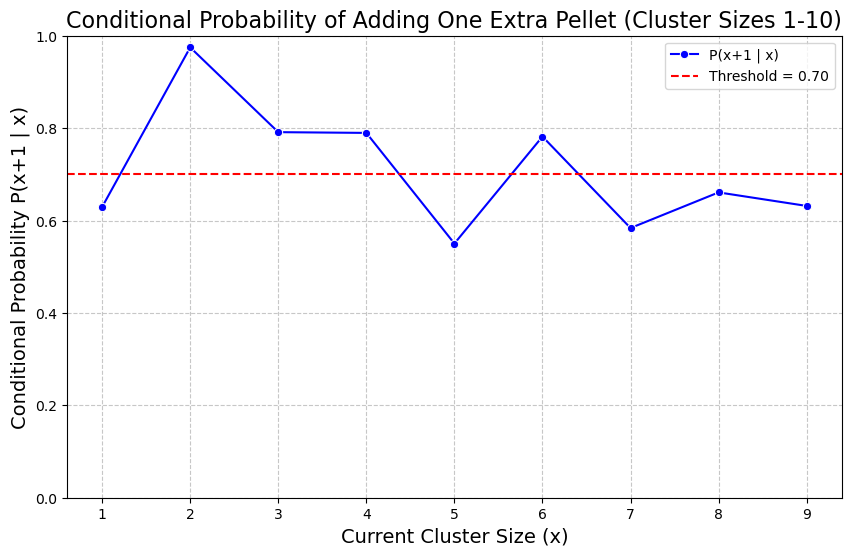

Determined Threshold based on Maximum Gap Method: 0.5502

Cluster Size | P(x+1 | x) | Delta P(x)
--------------------------------------
1            | 0.6293     | 0.3454    
2            | 0.9747     | -0.1835   
3            | 0.7913     | -0.0016   
4            | 0.7897     | -0.2394   
5            | 0.5502     | 0.2315    
6            | 0.7817     | -0.1980   
7            | 0.5838     | 0.0771    
8            | 0.6609     | -0.0293   

Delta P(x) for cluster sizes 1-10 (NR Phase, Order 1 Mice):
Delta P(1) = 0.3454
Delta P(2) = -0.1835
Delta P(3) = -0.0016
Delta P(4) = -0.2394
Delta P(5) = 0.2315
Delta P(6) = -0.1980
Delta P(7) = 0.0771
Delta P(8) = -0.0293


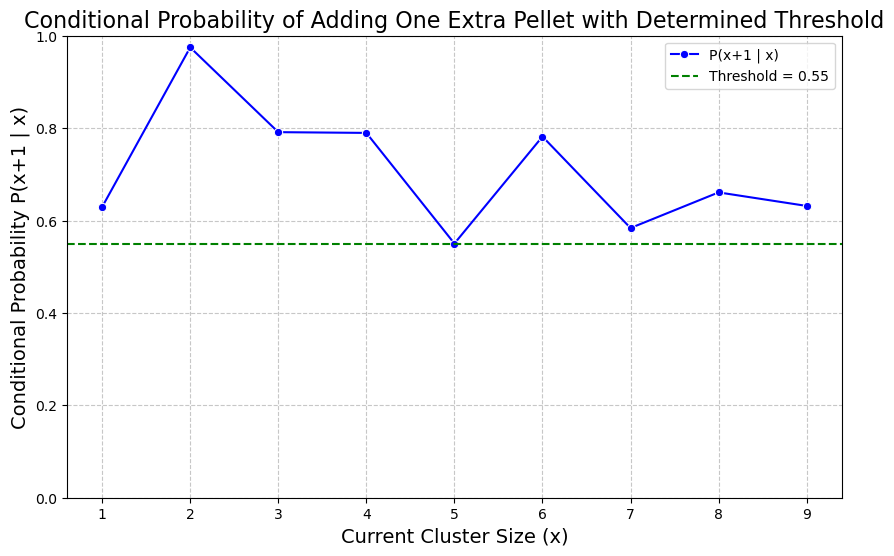


Mouse FEDXA07 - Phase NR with Threshold 0.55:
  Refined Meals: 150
  Refined Snacks: 45
  Refined Mega Meals: 124

Mouse FEDXA08 - Phase NR with Threshold 0.55:
  Refined Meals: 185
  Refined Snacks: 86
  Refined Mega Meals: 86

Mouse FEDXA09 - Phase NR with Threshold 0.55:
  Refined Meals: 174
  Refined Snacks: 62
  Refined Mega Meals: 114

Mouse FEDXA10 - Phase NR with Threshold 0.55:
  Refined Meals: 183
  Refined Snacks: 68
  Refined Mega Meals: 124

Mouse FEDXA11 - Phase NR with Threshold 0.55:
  Refined Meals: 195
  Refined Snacks: 163
  Refined Mega Meals: 100

Mouse FEDXA12 - Phase NR with Threshold 0.55:
  Refined Meals: 218
  Refined Snacks: 144
  Refined Mega Meals: 103

Mouse FEDXB07 - Phase NR with Threshold 0.55:
  Refined Meals: 183
  Refined Snacks: 75
  Refined Mega Meals: 127

Mouse FEDXB08 - Phase NR with Threshold 0.55:
  Refined Meals: 101
  Refined Snacks: 28
  Refined Mega Meals: 132

Mouse FEDXB10 - Phase NR with Threshold 0.55:
  Refined Meals: 335
  Refined S

In [22]:
import csv
from datetime import datetime
import numpy as np
import trompy as tp
import matplotlib.pyplot as plt
from collections import defaultdict
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint



# Function to compute conditional probabilities up to a specified max_size
def compute_conditional_probabilities_limited(mice, phases=['nr'], max_size=10, selectors=None):
    cluster_size_counts = defaultdict(int)
    
    # Aggregate cluster sizes across selected mice and phases
    for mouse_id, mouse_data in mice.items():
        # Apply selectors (e.g., Order 1)
        if selectors:
            skip = False
            for key, value in selectors.items():
                if mouse_data.get(key) != value:
                    skip = True
                    break
            if skip:
                continue
        
        for phase in phases:
            cluster_sizes = get_cluster_size_distribution_for_mouse(mouse_data.get(f"{phase}_timestamps", []))
            for size in cluster_sizes:
                if 1 <= size <= max_size:
                    cluster_size_counts[size] += 1
    
    # Sort cluster sizes
    sorted_sizes = sorted(cluster_size_counts.keys())
    
    # Compute conditional probabilities P(x+1 | x) for x = 1 to max_size -1
    conditional_probabilities = {}
    for size in sorted_sizes:
        if size >= max_size:
            continue  # We won't compute P(x+1|x) for x >= max_size
        count_x = cluster_size_counts[size]
        count_x_plus_1 = cluster_size_counts.get(size + 1, 0)
        if count_x == 0:
            conditional_probabilities[size] = 0.0
        else:
            P = count_x_plus_1 / count_x
            # Sanity check to ensure P <=1
            if P > 1.0:
                print(f"Anomaly detected: P({size + 1} | {size}) = {P:.4f} > 1.0. Setting P to 1.0")
                P = 1.0
            conditional_probabilities[size] = P
    
    return conditional_probabilities

# Function to plot conditional probabilities with a predefined threshold
def plot_conditional_probabilities_limited(conditional_probabilities, max_size=10, threshold=None):
    sizes = list(conditional_probabilities.keys())
    probabilities = list(conditional_probabilities.values())
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=sizes, y=probabilities, marker='o', color='blue', label='P(x+1 | x)')
    if threshold:
        plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.2f}')
    plt.xlabel('Current Cluster Size (x)', fontsize=14)
    plt.ylabel('Conditional Probability P(x+1 | x)', fontsize=14)
    plt.title('Conditional Probability of Adding One Extra Pellet (Cluster Sizes 1-10)', fontsize=16)
    plt.xticks(sizes)
    plt.ylim(0, 1)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

# Function to determine threshold using the maximum gap method
def determine_threshold_max_gap(conditional_probabilities):
    sorted_sizes = sorted(conditional_probabilities.keys())
    probs = [conditional_probabilities[size] for size in sorted_sizes]
    
    # Calculate differences between consecutive probabilities
    diffs = np.diff(probs)
    
    if len(diffs) == 0:
        print("Not enough data to determine threshold.")
        return 0.7, {}  # Default threshold and empty delta_p
    
    # Find the index of the maximum drop
    max_drop_index = np.argmin(diffs)
    
    # Set threshold slightly above the drop point
    threshold = probs[max_drop_index] + diffs[max_drop_index]
    
    # Ensure threshold is between 0 and 1
    threshold = min(max(threshold, 0.0), 1.0)
    
    # Create a dictionary for delta P(x)
    delta_p = {sorted_sizes[i]: diffs[i] for i in range(len(diffs))}
    
    print(f"Determined Threshold based on Maximum Gap Method: {threshold:.4f}")
    
    # Print the output in the desired format
    print("\nCluster Size | P(x+1 | x) | Delta P(x)")
    print("--------------------------------------")
    for i, size in enumerate(sorted_sizes[:-1]):
        print(f"{size:<12} | {probs[i]:<10.4f} | {delta_p.get(size, 0.0):<10.4f}")
    
    return threshold, delta_p

# Function to plot conditional probabilities with determined threshold
def plot_conditional_probabilities_with_determined_threshold(conditional_probabilities, threshold, max_size=10):
    sizes = list(conditional_probabilities.keys())
    probabilities = list(conditional_probabilities.values())
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=sizes, y=probabilities, marker='o', color='blue', label='P(x+1 | x)')
    plt.axhline(y=threshold, color='green', linestyle='--', label=f'Threshold = {threshold:.2f}')
    plt.xlabel('Current Cluster Size (x)', fontsize=14)
    plt.ylabel('Conditional Probability P(x+1 | x)', fontsize=14)
    plt.title('Conditional Probability of Adding One Extra Pellet with Determined Threshold', fontsize=16)
    plt.xticks(sizes)
    plt.ylim(0, 1)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

# Function to refine meal metrics based on conditional probabilities
def get_refined_meal_and_snack_metrics_limited(pellettimes, conditional_probabilities, prob_threshold=0.7, ipi_threshold=60):
    if not pellettimes:
        return ([], [], [])  # meals, snacks, mega_meals
    
    # Cluster pellets based on IPI
    clusters = cluster_pellets_by_ipi(pellettimes, ipi_threshold=ipi_threshold)
    refined_meals = []
    refined_snacks = []
    refined_mega_meals = []
    
    for cluster in clusters:
        cluster_size = len(cluster)
        # Only consider cluster sizes up to 10
        if cluster_size > 10:
            refined_mega_meals.append(cluster)
            continue
        
        # Get conditional probability P(x+1 | x) if applicable
        P_add = conditional_probabilities.get(cluster_size, 0.0)
        
        if cluster_size == 1:
            refined_snacks.append(cluster)
        elif 2 <= cluster_size <= 4:
            if P_add < prob_threshold:
                refined_meals.append(cluster)
            else:
                refined_meals.append(cluster)
        elif 5 <= cluster_size <= 10:
            if P_add < prob_threshold:
                refined_meals.append(cluster)
            else:
                refined_mega_meals.append(cluster)
        else:
            refined_mega_meals.append(cluster)
    
    return (refined_meals, refined_snacks, refined_mega_meals)

# Function to integrate refined meals based on conditional probabilities
def integrate_refined_meals_limited(mice, conditional_probabilities, phases=['nr'], prob_threshold=0.7, ipi_threshold=60, selectors=None):
    for mouse_id, mouse_data in mice.items():
        # Apply selectors (e.g., Order 1)
        if selectors:
            skip = False
            for key, value in selectors.items():
                if mouse_data.get(key) != value:
                    skip = True
                    break
            if skip:
                continue
        
        for phase in phases:
            pellettimes = mouse_data.get(f"{phase}_timestamps", [])
            if not pellettimes:
                continue
            # Get refined metrics
            refined_meals, refined_snacks, refined_mega_meals = get_refined_meal_and_snack_metrics_limited(
                pellettimes, 
                conditional_probabilities, 
                prob_threshold=prob_threshold, 
                ipi_threshold=ipi_threshold
            )
            # Update the mice dictionary
            mice[mouse_id][f"{phase}_refined_meals"] = refined_meals
            mice[mouse_id][f"{phase}_refined_snacks"] = refined_snacks
            mice[mouse_id][f"{phase}_refined_mega_meals"] = refined_mega_meals
            
            # Update counts and other metrics if needed
            mice[mouse_id][f"{phase}_refined_number_of_meals"] = len(refined_meals)
            mice[mouse_id][f"{phase}_refined_number_of_snacks"] = len(refined_snacks)
            mice[mouse_id][f"{phase}_refined_number_of_mega_meals"] = len(refined_mega_meals)
    
    return mice

# Example usage:
if __name__ == "__main__":
    # Assuming 'mice' dictionary is already populated with data
    # Define selectors for Order 1 mice
    selectors = {'order': 1}  # Adjust based on your data structure
    
    # Step 1: Compute conditional probabilities limited to 'nr' phase and Order 1 mice
    conditional_probabilities = compute_conditional_probabilities_limited(
        mice, 
        phases=['nr'], 
        max_size=10, 
        selectors=selectors
    )
    
    print("\nConditional Probabilities P(x+1 | x) for cluster sizes 1-10 (NR Phase, Order 1 Mice):")
    for size in sorted(conditional_probabilities.keys()):
        print(f"P({size + 1} | {size}) = {conditional_probabilities[size]:.4f}")
    
    # Step 2: Plot conditional probabilities with initial threshold (e.g., 0.7)
    plot_conditional_probabilities_limited(conditional_probabilities, max_size=10, threshold=0.7)
    
    # Step 3: Determine threshold using Maximum Gap Method
    determined_threshold, delta_p = determine_threshold_max_gap(conditional_probabilities)
    
    print("\nDelta P(x) for cluster sizes 1-10 (NR Phase, Order 1 Mice):")
    for size in sorted(delta_p.keys()):
        print(f"Delta P({size}) = {delta_p[size]:.4f}")
    
    # Step 4: Plot with determined threshold
    plot_conditional_probabilities_with_determined_threshold(conditional_probabilities, determined_threshold, max_size=10)
    
    # Step 5: Integrate refined meal definitions using the determined threshold
    mice = integrate_refined_meals_limited(
        mice, 
        conditional_probabilities, 
        phases=['nr'], 
        prob_threshold=determined_threshold, 
        ipi_threshold=60, 
        selectors=selectors
    )
    
    # Step 6: Review the refined meal counts for each mouse and phase
    for mouse_id, mouse_data in mice.items():
        # Apply selectors to ensure only Order 1 mice are considered
        if selectors:
            skip = False
            for key, value in selectors.items():
                if mouse_data.get(key) != value:
                    skip = True
                    break
            if skip:
                continue
        
        for phase in ['nr']:
            refined_meals = mouse_data.get(f"{phase}_refined_meals", [])
            refined_snacks = mouse_data.get(f"{phase}_refined_snacks", [])
            refined_mega_meals = mouse_data.get(f"{phase}_refined_mega_meals", [])
            print(f"\nMouse {mouse_id} - Phase {phase.upper()} with Threshold {determined_threshold:.2f}:")
            print(f"  Refined Meals: {len(refined_meals)}")
            print(f"  Refined Snacks: {len(refined_snacks)}")
            print(f"  Refined Mega Meals: {len(refined_mega_meals)}")


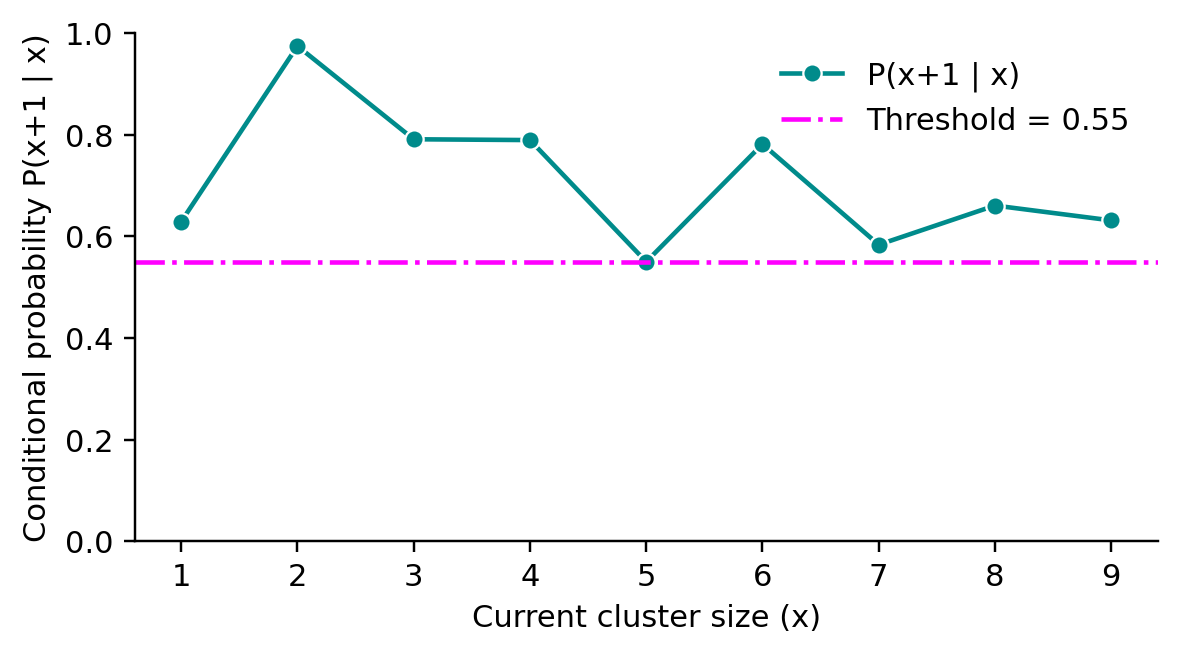

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_conditional_probabilities_with_determined_threshold(conditional_probabilities, threshold, max_size=10):
    sizes = list(conditional_probabilities.keys())
    probabilities = list(conditional_probabilities.values())
    
    plt.figure(figsize=(6, 3), dpi=220)
    sns.lineplot(x=sizes, y=probabilities, marker='o', color='darkcyan', label='P(x+1 | x)')
    plt.axhline(y=threshold, color='magenta', linestyle='-.', label=f'Threshold = {threshold:.2f}')
    plt.xlabel('Current cluster size (x)', fontsize=10)
    plt.ylabel('Conditional probability P(x+1 | x)', fontsize=10)
    plt.title('', fontsize=16)
    plt.xticks(sizes)
    plt.ylim(0, 1)
    plt.legend(frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # plt.show()

# Example usage:
plot_conditional_probabilities_with_determined_threshold(conditional_probabilities, 0.55, max_size=10)

# Save the plot to a file
#filename = "..//plots/NEW_MEAL_PLOTS//Conditional_Probabilities.png"
#plt.savefig(filename, dpi=220, bbox_inches='tight')
#plt.close()
#print(f"Plot saved as {filename}")




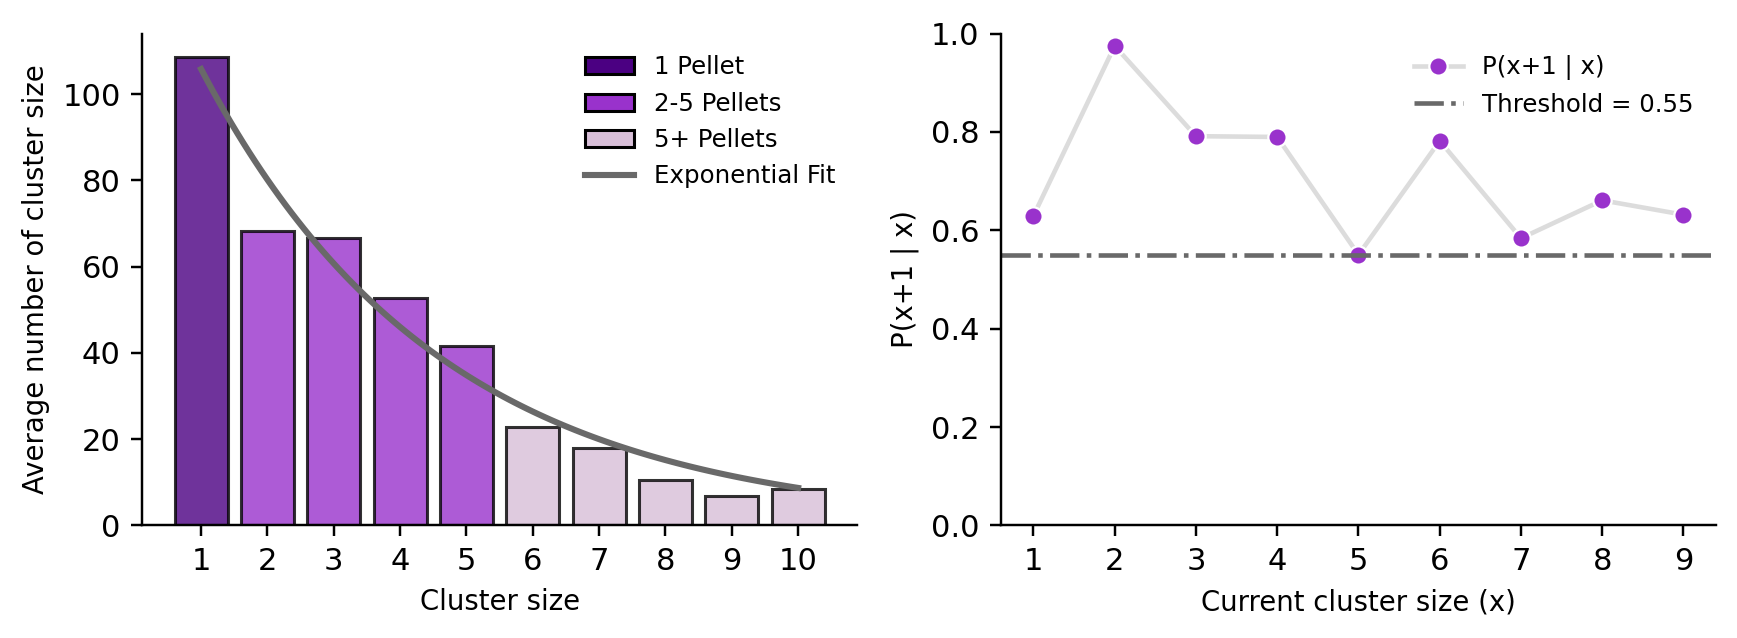

Plot saved as ..//plots/sup_plots//Combined_Cluster_Probabilities.png


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from matplotlib.patches import Patch


def exponential_decay(x, a, b):
    return a * np.exp(-b * x)


sizes = np.arange(1, len(combined_avg_cluster_sizes) + 1)
avg_cluster_sizes = np.array(combined_avg_cluster_sizes)  # 

# Fit the exponential curve to the actual data
params, _ = curve_fit(exponential_decay, sizes, avg_cluster_sizes, p0=(50, 0.2))

# Extract parameters for plotting
a, b = params

# Generate smooth curve for the exponential fit
x_fit = np.linspace(1, len(combined_avg_cluster_sizes), 100)
y_fit = exponential_decay(x_fit, a, b)

# Create a single figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=220)

# Define colors for bars based on pellet clusters
colors = ['indigo' if size == 1 else 'darkorchid' if 2 <= size <= 5 else 'thistle' for size in sizes]

### **Plot 1: Cluster Size Distribution + Exponential Fit**
ax1 = axes[0]
ax1.bar(sizes, avg_cluster_sizes, color=colors, edgecolor='black', alpha=0.8, label="Average Cluster Size")
ax1.plot(x_fit, y_fit, color='dimgray', linestyle='solid', linewidth=2, label="Exponential Fit")

ax1.set_xlabel('Cluster size', fontsize=9)
ax1.set_ylabel('Average number of cluster size', fontsize=9)
ax1.set_xticks(sizes)
ax1.set_title('', fontsize=10)

# Legend setup
legend_elements = [
    Patch(facecolor='indigo', edgecolor='black', label='1 Pellet'),
    Patch(facecolor='darkorchid', edgecolor='black', label='2-5 Pellets'),
    Patch(facecolor='thistle', edgecolor='black', label='5+ Pellets')
]
ax1.legend(handles=legend_elements + [plt.Line2D([0], [0], color='dimgray', linestyle='solid', linewidth=2, label="Exponential Fit")],
           frameon=False, fontsize=8, loc="upper right")

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)


### **Plot 2: Conditional Probabilities**
ax2 = axes[1]
sizes_prob = list(conditional_probabilities.keys())
probabilities = list(conditional_probabilities.values())

sns.lineplot(
    x=sizes_prob, y=probabilities, marker='o', color='gainsboro',
    markerfacecolor='darkorchid', markersize=6, label='P(x+1 | x)', ax=ax2
)
ax2.axhline(y=0.55, color='dimgray', linestyle='-.', label=f'Threshold = 0.55')

ax2.set_xlabel('Current cluster size (x)', fontsize=9)
ax2.set_ylabel('P(x+1 | x)', fontsize=9)
ax2.set_xticks(sizes_prob)
ax2.set_ylim(0, 1)
ax2.set_title('', fontsize=10)

ax2.legend(frameon=False, fontsize=8, loc="upper right")
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Adjust layout and save
plt.tight_layout()
filename = r"..//plots/sup_plots//Combined_Cluster_Probabilities.png"
plt.savefig(filename, dpi=220, bbox_inches='tight')
plt.show()

print(f"Plot saved as {filename}")


# so after all, this should be what we use in the paper/sup file

C:\Users\hta031\AppData\Local\Temp\ipykernel_25764\2014828263.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


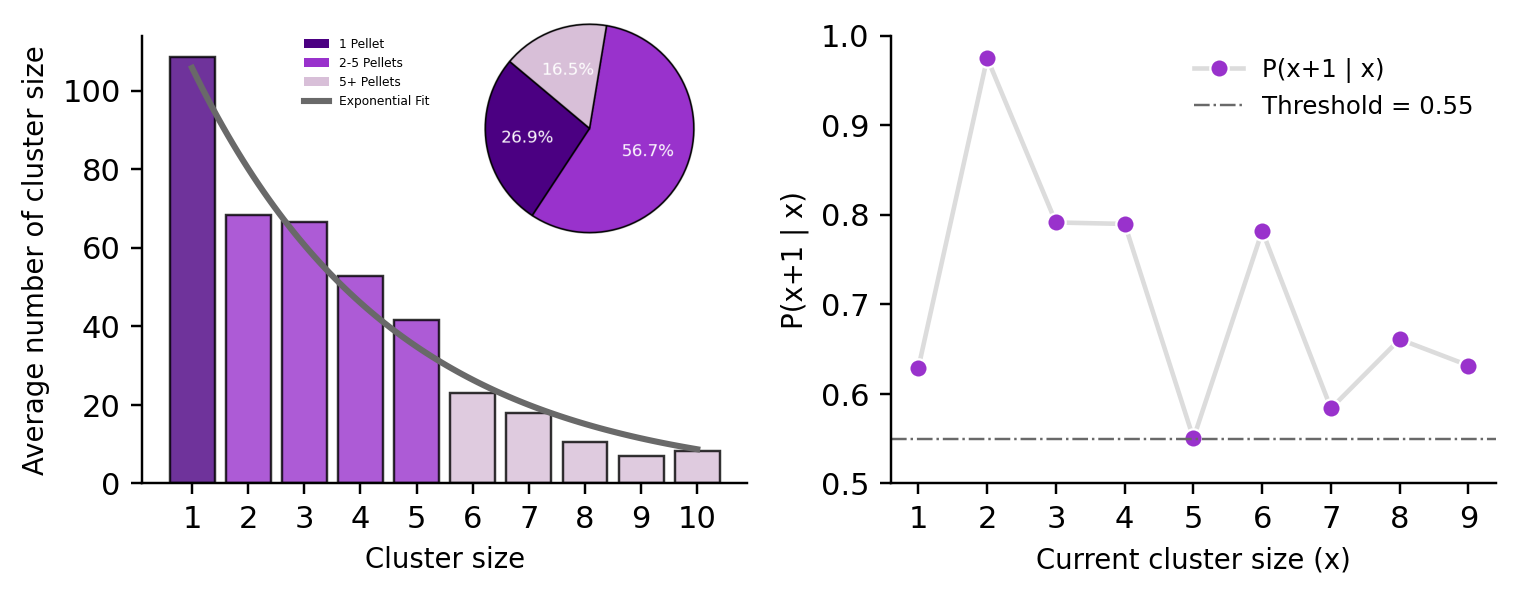

Plot saved as ..//plots//sup_plots//Final_Cluster_Plot_with_Pie_Corrected.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from matplotlib.patches import Patch
import matplotlib.image as mpimg

# Define the exponential decay function
def exponential_decay(x, a, b):
    return a * np.exp(-b * x)

sizes = np.arange(1, len(combined_avg_cluster_sizes) + 1)
avg_cluster_sizes = np.array(combined_avg_cluster_sizes)


params, _ = curve_fit(exponential_decay, sizes, avg_cluster_sizes, p0=(50, 0.2))
a, b = params

x_fit = np.linspace(1, len(combined_avg_cluster_sizes), 100)
y_fit = exponential_decay(x_fit, a, b)

# Create a single figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(7, 2.8), dpi=220)

# Define colors for bars based on pellet clusters
colors = ['indigo' if size == 1 else 'darkorchid' if 2 <= size <= 5 else 'thistle' for size in sizes]

### **Plot 1: Cluster Size Distribution + Exponential Fit**
ax1 = axes[0]
ax1.bar(sizes, avg_cluster_sizes, color=colors, edgecolor='black', alpha=0.8, linewidth=0.8, width=0.8)
ax1.plot(x_fit, y_fit, color='dimgray', linestyle='solid', linewidth=2)

ax1.set_xlabel('Cluster size', fontsize=9)
ax1.set_ylabel('Average number of cluster size', fontsize=9)
ax1.set_xticks(sizes)

# **Reduce legend size and move it slightly toward the center**
legend_elements = [
    Patch(facecolor='indigo', label='1 Pellet'),
    Patch(facecolor='darkorchid', label='2-5 Pellets'),
    Patch(facecolor='thistle', label='5+ Pellets'),
    plt.Line2D([0], [0], color='dimgray', linestyle='solid', linewidth=2, label="Exponential Fit")
]
ax1.legend(handles=legend_elements, frameon=False, fontsize=4, loc="upper left", bbox_to_anchor=(0.25, 1.02))

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)


pie_img = mpimg.imread(r"..//plots//sup_plots//Order1_NR_Food_Pie.png")
pie_ax = fig.add_axes([0.3, 0.6, 0.18, 0.35]) 
pie_ax.imshow(pie_img)
pie_ax.axis('off')  


ax2 = axes[1]
sizes_prob = list(conditional_probabilities.keys())
probabilities = list(conditional_probabilities.values())

sns.lineplot(
    x=sizes_prob, y=probabilities, marker='o', color='gainsboro',
    markerfacecolor='darkorchid', markersize=6, label='P(x+1 | x)', ax=ax2
)


threshold_line = ax2.axhline(y=0.55, color='dimgray', linestyle='-.', linewidth=0.8, label="Threshold = 0.55")

ax2.set_xlabel('Current cluster size (x)', fontsize=9)
ax2.set_ylabel('P(x+1 | x)', fontsize=9)
ax2.set_xticks(sizes_prob)


ax2.set_ylim(0.5, 1)
ax2.set_yticks(np.arange(0.5, 1.05, 0.1))  # Tick marks at 0.5, 0.6, ..., 1.0

ax2.legend(frameon=False, fontsize=8, loc="upper right")

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Adjust layout and save
plt.tight_layout()
filename = r"..//plots//sup_plots//Final_Cluster_Plot_with_Pie_Corrected.png"
plt.savefig(filename, dpi=220, bbox_inches='tight')
plt.show()

print(f"Plot saved as {filename}")


In [42]:
from collections import defaultdict
from statsmodels.stats.proportion import proportion_confint

def compute_confidence_intervals_limited(mice, phases=('nr',), max_size=10,
                                         selectors=None, alpha=0.05):
    """
    Compute Wilson 95% confidence intervals for P(x+1 | x),
    where P(x+1 | x) = n_{x+1} / n_x and n_x is the total number
    of clusters of size x across all selected mice and phases.
    """
    cluster_size_counts = defaultdict(int)  # n_x
    
    # 1) Aggregate cluster sizes across selected mice and phases
    for mouse_id, mouse_data in mice.items():
        # Apply selectors (e.g. order == 1)
        if selectors:
            if any(mouse_data.get(k) != v for k, v in selectors.items()):
                continue
        
        for phase in phases:
            pellettimes = mouse_data.get(f"{phase}_timestamps", [])
            if not pellettimes:
                continue
            cluster_sizes = get_cluster_size_distribution_for_mouse(pellettimes)
            for size in cluster_sizes:
                if 1 <= size <= max_size:
                    cluster_size_counts[size] += 1
    
    # 2) Compute Wilson CIs for P(x+1 | x) for x = 1..max_size-1
    confidence_intervals = {}
    for x in range(1, max_size):  # x = 1..9 when max_size=10
        n_x    = cluster_size_counts[x]             # denominator
        n_next = cluster_size_counts.get(x + 1, 0)  # numerator
        if n_x > 0:
            ci_low, ci_upp = proportion_confint(n_next, n_x,
                                                alpha=alpha,
                                                method='wilson')
            confidence_intervals[x] = (ci_low, ci_upp)
        else:
            confidence_intervals[x] = (float('nan'), float('nan'))
    
    return confidence_intervals


# Compute confidence intervals with 95% confidence level
confidence_intervals = compute_confidence_intervals_limited(
    mice, 
    phases=['nr'], 
    max_size=10, 
    selectors={'order': 1}, 
    alpha=0.05
)

print("\nConfidence Intervals for P(x+1 | x):")
for size, ci in sorted(confidence_intervals.items()):
    print(f"P({size +1} | {size}) = {conditional_probabilities[size]:.4f} (95% CI: {ci[0]:.4f} - {ci[1]:.4f})")



Confidence Intervals for P(x+1 | x):
P(2 | 1) = 0.6293 (95% CI: 0.6015 - 0.6562)
P(3 | 2) = 0.9747 (95% CI: 0.9609 - 0.9838)
P(4 | 3) = 0.7913 (95% CI: 0.7604 - 0.8191)
P(5 | 4) = 0.7897 (95% CI: 0.7546 - 0.8209)
P(6 | 5) = 0.5502 (95% CI: 0.5044 - 0.5952)
P(7 | 6) = 0.7817 (95% CI: 0.7267 - 0.8283)
P(8 | 7) = 0.5838 (95% CI: 0.5140 - 0.6503)
P(9 | 8) = 0.6609 (95% CI: 0.5704 - 0.7409)
P(10 | 9) = 0.6316 (95% CI: 0.5193 - 0.7312)
